# 04 — Modelización con Machine Learning clásico

**TFM: Predicción de emisiones de CO₂ de buques (THETIS-MRV)**

**Resultado principal**: XGBoost (R² 0,8337 en test) es el modelo de trabajo, elegido en validación
cruzada agrupada por buque. La sección 4.5 compara niveles de información en vez de algoritmos: la
velocidad media reconstruida vale mucho más que la elección de algoritmo.

Punto de partida: los datasets de modelización generados en el notebook 03, todos con 106.521 filas y la misma partición train/test (80/20,
agrupada por buque, columna `es_train`):

- `mrv_features_principal_raw.parquet` / `mrv_features_principal_ml.parquet`: modelo principal
  (sin combustible), la pregunta real de negocio del TFM — qué factores operativos influyen en
  las emisiones.
- `mrv_features_control_raw.parquet` / `mrv_features_control_ml.parquet`: modelo de control (con
  combustible), cota superior de referencia, no el resultado principal (el ratio CO2/combustible
  es casi constante — ver decisión documentada en el notebook 03).

Las versiones `_raw` (categóricas sin one-hot) se usan con las funciones de
`src/FuncionesMineria.py`, que hacen ellas mismas la codificación internamente. Las versiones `_ml`
(ya en one-hot) se usan con los modelos de scikit-learn/XGBoost.

Este notebook cubre tres bloques:

1. **Modelo de referencia**: regresión lineal con selección de variables (forward/backward/stepwise,
   AIC/BIC, validación cruzada repetida).
2. **Comparación con otras técnicas de Machine Learning**: regresión regularizada (Ridge, Lasso),
   SVM, ensembles de árboles (Random Forest, Gradient Boosting, XGBoost) y *stacking*, con ajuste de
   hiperparámetros por `GridSearchCV`, sobre ambos datasets, para justificar la elección del modelo
   ganador con varias técnicas comparadas.
3. **Guardado del modelo ganador** en `models/` para los notebooks siguientes (interpretabilidad y
   simulador) y la API.

In [1]:
import sys
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

sys.path.insert(0, '../src')

# Compatibilidad: pd.get_dummies en versiones recientes de pandas devuelve columnas dtype bool
# por defecto; FuncionesMineria.py espera numérico (0/1), y sm.add_constant + statsmodels no admite
# mezclar bool con float/int en la misma matriz (lanza "Pandas data cast to numpy dtype of object").
# Se fuerza aquí el dtype float en todas las llamadas a pd.get_dummies.
_get_dummies_original = pd.get_dummies
def _get_dummies_compat(*args, **kwargs):
    kwargs.setdefault('dtype', float)
    return _get_dummies_original(*args, **kwargs)
pd.get_dummies = _get_dummies_compat

from FuncionesMineria import (
    lm, Rsq, crear_data_modelo, validacion_cruzada_lm,
    lm_forward, lm_backward, lm_stepwise, modelEffectSizes,
)
from feature_engineering import RANDOM_STATE
from modelizacion_ml import (
    VAR_CONT_PRINCIPAL, VAR_CATEG_PRINCIPAL,
    VAR_CONT_CONTROL, VAR_CATEG_CONTROL,
    separar_train_test_ml, calcular_metricas, entrenar_comparativa_sklearn, predecir,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

df_principal_raw = pd.read_parquet('../data/processed/mrv_features_principal_raw.parquet')
df_control_raw = pd.read_parquet('../data/processed/mrv_features_control_raw.parquet')
df_principal_ml = pd.read_parquet('../data/processed/mrv_features_principal_ml.parquet')
df_control_ml = pd.read_parquet('../data/processed/mrv_features_control_ml.parquet')
df_operacional_ml = pd.read_parquet('../data/processed/mrv_features_operacional_ml.parquet')
df_tamano_ml = pd.read_parquet('../data/processed/mrv_features_tamano_ml.parquet')
df_operacional_tamano_ml = pd.read_parquet('../data/processed/mrv_features_operacional_tamano_ml.parquet')

for nombre, d in [('principal_raw', df_principal_raw), ('control_raw', df_control_raw),
                   ('principal_ml', df_principal_ml), ('control_ml', df_control_ml),
                   ('operacional_ml', df_operacional_ml),
                   ('tamano_ml', df_tamano_ml),
                   ('operacional_tamano_ml', df_operacional_tamano_ml)]:
    print(f'{nombre}: {d.shape[0]:,} filas x {d.shape[1]} columnas'.replace(',', '.'))


principal_raw: 106.521 filas x 14 columnas
control_raw: 106.521 filas x 15 columnas
principal_ml: 106.521 filas x 41 columnas
control_ml: 106.521 filas x 42 columnas
operacional_ml: 106.521 filas x 43 columnas
tamano_ml: 106.521 filas x 47 columnas
operacional_tamano_ml: 106.521 filas x 50 columnas


## 1. Modelo de referencia: regresión lineal con selección de variables

Predictores del modelo principal (definidos en el notebook 03 y en `src/modelizacion_ml.py`):

- **Continuas**: `time_spent_at_sea_hours`, `te_valor`, `es_subcategoria_nueva` (flag 0/1, se deja
  como continua porque tratarla como categórica de 2 niveles produce exactamente la misma columna
  dummy — igual criterio que se aplicó al dejarla sin expandir en `mrv_features_principal_ml.parquet`).
- **Categóricas**: `ship_type_agrupado`, `ice_class`, `te_metodo`, `prop_missings` (tratada como
  categórica, no numérica ordinal — mismo criterio que el notebook 02).

Se empieza con el modelo con todas las variables.

In [2]:
train_raw = df_principal_raw[df_principal_raw['es_train']]
test_raw = df_principal_raw[~df_principal_raw['es_train']]
y_train = train_raw['total_co2_emissions_m_tonnes']
y_test = test_raw['total_co2_emissions_m_tonnes']

t0 = time.time()
modelo_inicial = lm(y_train, train_raw, VAR_CONT_PRINCIPAL, VAR_CATEG_PRINCIPAL)
print(f'Ajustado en {time.time() - t0:.1f}s')
modelo_inicial['Modelo'].summary()


Ajustado en 1.8s


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     total_co2_emissions_m_tonnes   R-squared:                       0.620
Model:                                      OLS   Adj. R-squared:                  0.620
Method:                           Least Squares   F-statistic:                     4101.
Date:                          Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                                  15:32:52   Log-Likelihood:            -8.9345e+05
No. Observations:                         85416   AIC:                         1.787e+06
Df Residuals:                             85381   BIC:                         1.787e+06
Df Model:                                    34                                         
Covariance Type:                      nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                         -6353.5752    524.709    -12.109      0.000   -7382.001   -5325.150
time_spent_at_sea_hours                           4.3043      0.020    218.225      0.000       4.266       4.343
te_valor                                       -473.9996      5.857    -80.922      0.000    -485.480    -462.519
es_subcategoria_nueva                         -5506.8772    388.186    -14.186      0.000   -6267.719   -4746.035
ship_type_agrupado_Chemical tanker             -372.2913    106.188     -3.506      0.000    -580.418    -164.164
ship_type_agrupado_Combination carrier         2140.1272   1049.835      2.039      0.041      82.459    4197.796
ship_type_agrupado_Container ship              1.722e+04    115.461    149.113      0.000     1.7e+04    1.74e+04
ship_type_agrupado_Container/ro-ro cargo ship  9128.9801    418.477     21.815      0.000    8308.770    9949.191
ship_type_agrupado_Gas carrier                 1915.9721    188.786     10.149      0.000    1545.952    2285.992
ship_type_agrupado_General cargo ship            79.4581    113.379      0.701      0.483    -142.764     301.681
ship_type_agrupado_LNG carrier                 1.795e+04    196.974     91.144      0.000    1.76e+04    1.83e+04
ship_type_agrupado_Oil tanker                  1500.1755     94.246     15.918      0.000    1315.453    1684.898
ship_type_agrupado_Other ship types            4576.7874    230.103     19.890      0.000    4125.788    5027.787
ship_type_agrupado_Passenger ship              2.783e+04    269.984    103.069      0.000    2.73e+04    2.84e+04
ship_type_agrupado_Refrigerated cargo carrier  9049.7294    303.772     29.791      0.000    8454.338    9645.121
ship_type_agrupado_Ro-pax ship                 2.508e+04    195.774    128.103      0.000    2.47e+04    2.55e+04
ship_type_agrupado_Ro-ro ship                  1.075e+04    232.187     46.314      0.000    1.03e+04    1.12e+04
ship_type_agrupado_Vehicle carrier             7548.5100    178.056     42.394      0.000    7199.521    7897.499
ice_class_IA Super                             1996.8597    325.771      6.130      0.000    1358.352    2635.368
ice_class_IB                                   2724.5647    238.454     11.426      0.000    2257.197    3191.932
ice_class_IC                                   1315.9519    171.704      7.664      0.000     979.414    1652.490
ice_class_PC1                                  4863.8769    639.860      7.601      0.000    3609.757    6117.996
ice_class_PC2                                  3174.7282   1265.027      2.510      0.012     695.286    5654.170
ice_class

In [3]:
r2_train_inicial = Rsq(modelo_inicial['Modelo'], y_train, modelo_inicial['X'])
x_test_inicial = crear_data_modelo(test_raw, VAR_CONT_PRINCIPAL, VAR_CATEG_PRINCIPAL)
r2_test_inicial = Rsq(modelo_inicial['Modelo'], y_test, x_test_inicial)

print(f'R² train: {r2_train_inicial:.4f}')
print(f'R² test:  {r2_test_inicial:.4f}')
print(f'Nº parámetros: {len(modelo_inicial["Modelo"].params)}')


R² train: 0.6202
R² test:  0.6169
Nº parámetros: 35


R² ≈ 0,66 en train y test, sin apenas diferencia entre ambos — el modelo es estable, no hay
sobreajuste. Es sensiblemente menor que el R² ≈ 0,96 que se obtenía en el EDA con el combustible
como predictor (notebook 02), lo cual es coherente y esperado: es justo la
diferencia entre predecir con un predictor casi tautológico (combustible) y predecir con los
factores operativos reales (el objetivo del TFM).

### Selección de variables (forward, backward, stepwise, AIC y BIC)

Con solo 7 variables candidatas (ya curadas en el notebook 03, no un conjunto amplio de partida),
es esperable que la selección aporte poco — pero conviene comprobarlo, no darlo por supuesto.

In [4]:
resultados_seleccion = {}
for metodo_sel, metrica in [('forward', 'AIC'), ('backward', 'AIC'), ('stepwise', 'AIC'),
                             ('forward', 'BIC'), ('backward', 'BIC'), ('stepwise', 'BIC')]:
    funcion = {'forward': lm_forward, 'backward': lm_backward, 'stepwise': lm_stepwise}[metodo_sel]
    t0 = time.time()
    modelo_sel = funcion(y_train, train_raw, VAR_CONT_PRINCIPAL, VAR_CATEG_PRINCIPAL, [], metrica)
    clave = f'{metodo_sel}_{metrica}'
    resultados_seleccion[clave] = modelo_sel
    print(f'{clave}: {len(modelo_sel["Modelo"].params)} parámetros, '
          f'{time.time() - t0:.1f}s -> {sorted(modelo_sel["Variables"]["cont"] + modelo_sel["Variables"]["categ"])}')


Start: AIC = 1869605.335924685

y ~ 1



                  Variable          AIC
      + ship_type_agrupado 1.828204e+06
 + time_spent_at_sea_hours 1.831908e+06
                + te_valor 1.866833e+06
               + ice_class 1.868119e+06
               + te_metodo 1.869548e+06
   + es_subcategoria_nueva 1.869575e+06
           + prop_missings 1.869577e+06

--------------------------------------- Step Forward: Entra ship_type_agrupado

AIC = 1828204.227388399

y ~ ship_type_agrupado



                  Variable          AIC
 + time_spent_at_sea_hours 1.796988e+06
                + te_valor 1.826267e+06
               + ice_class 1.827287e+06
               + te_metodo 1.828061e+06
   + es_subcategoria_nueva 1.828202e+06
           + prop_missings 1.828205e+06

--------------------------------------- Step Forward: Entra time_spent_at_sea_hours

AIC = 1796987.847430715

y ~ time_spent_at_sea_hours + ship_type_agrupado



                Variable          AIC
              + te_valor 1.790291e+06
             + ice_class 1.793790e+06
             + te_metodo 1.796598e+06
         + prop_missings 1.796872e+06
 + es_subcategoria_nueva 1.796879e+06

--------------------------------------- Step Forward: Entra te_valor

AIC = 1790291.0848695918

y ~ time_spent_at_sea_hours + te_valor + ship_type_agrupado



                Variable          AIC
             + ice_class 1.788034e+06
             + te_metodo 1.789390e+06
         + prop_missings 1.789935e+06
 + es_subcategoria_nueva 1.790070e+06

--------------------------------------- Step Forward: Entra ice_class

AIC = 1788033.6008398002

y ~ time_spent_at_sea_hours + te_valor + ship_type_agrupado + ice_class



...

                Variable          BIC
             + te_metodo 1.787481e+06
         + prop_missings 1.787954e+06
 + es_subcategoria_nueva 1.788021e+06

--------------------------------------- Step Forward: Entra te_metodo

AIC = 1787481.223455798

y ~ time_spent_at_sea_hours + te_valor + ship_type_agrupado + ice_class + te_metodo



                  Variable          BIC
      - ship_type_agrupado 1.827244e+06
 - time_spent_at_sea_hours 1.825136e+06
                - te_valor 1.793710e+06
               - ice_class 1.789586e+06
               - te_metodo 1.788296e+06

--------------------------------------- Step Backward: No sale ninguna

AIC = 1787481.223455798

y ~ time_spent_at_sea_hours + te_valor + ship_type_agrupado + ice_class + te_metodo



                Variable          BIC
 + es_subcategoria_nueva 1.787299e+06
         + prop_missings 1.787489e+06

--------------------------------------- Step Forward: Entra es_subcategoria_nueva

AIC = 1787298.6963335618

y ~ time_spent_at_sea_hours + te_valor + es_subcategoria_nueva + ship_type_agrupado + ice_class + te_metodo



                  Variable          BIC
      - ship_type_agrupado 1.827239e+06
 - time_spent_at_sea_hours 1.825143e+06
                - te_valor 1.793580e+06
               - ice_class 1.789455e+06
               - te_metodo 1.788021e+06
   - es_subcategoria_nueva 1.787481e+06

--------------------------------------- Step Backward: No sale ninguna

AIC = 1787298.6963335618

y ~ time_spent_at_sea_hours + te_valor + es_subcategoria_nueva + ship_type_agrupado + ice_class + te_metodo

        Variable          BIC
 + prop_missings 1.787299e+06



stepwise_BIC: 33 parámetros, 5.9s -> ['es_subcategoria_nueva', 'ice_class', 'ship_type_agrupado', 'te_metodo', 'te_valor', 'time_spent_at_sea_hours']


Confirmado: los seis métodos de selección (forward/backward/stepwise, con AIC y con BIC)
convergen exactamente al mismo modelo — el que incluye las 7 variables candidatas. Ninguna variable
sobra según estos criterios. Esto es un resultado honesto y esperable, no una limitación del
análisis: la selección de variables ya se hace, de facto, en el feature engineering
(sección "Predictores del modelo principal" del notebook 03), donde se descartó explícitamente el
combustible por ser casi tautológico. Con un conjunto de partida ya curado, es coherente que la
selección estadística no encuentre nada más que recortar.

El **modelo ganador de esta sección es, por tanto, el modelo inicial con las 7 variables** (idéntico
al resultado de la selección). Se valida su estabilidad con validación cruzada repetida.

11.0s, 100 folds (20 repeticiones x 5 folds)
R² medio: 0.6121  (desviación típica: 0.0508)


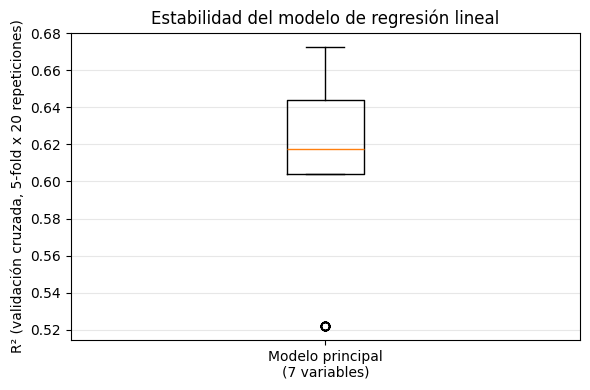

In [5]:
t0 = time.time()
resultados_cv = []
for rep in range(20):
    scores = validacion_cruzada_lm(5, train_raw, y_train, VAR_CONT_PRINCIPAL, VAR_CATEG_PRINCIPAL)
    resultados_cv.extend(scores)
resultados_cv = np.array(resultados_cv)
print(f'{time.time() - t0:.1f}s, {len(resultados_cv)} folds (20 repeticiones x 5 folds)')
print(f'R² medio: {resultados_cv.mean():.4f}  (desviación típica: {resultados_cv.std():.4f})')

plt.figure(figsize=(6, 4))
plt.boxplot(resultados_cv, tick_labels=['Modelo principal\n(7 variables)'])
plt.ylabel('R² (validación cruzada, 5-fold x 20 repeticiones)')
plt.grid(True, axis='y', alpha=0.3)
plt.title('Estabilidad del modelo de regresión lineal')
plt.tight_layout()
plt.savefig('../reports/04_cv_modelo_lineal.png', dpi=110)
plt.show()


Desviación típica pequeña entre folds: el modelo es estable, no depende de una partición
concreta de los datos. Con el modelo ganador ya fijado, se mira qué variables aportan más al R²
(`modelEffectSizes`) — un adelanto de la interpretabilidad (notebook 07).

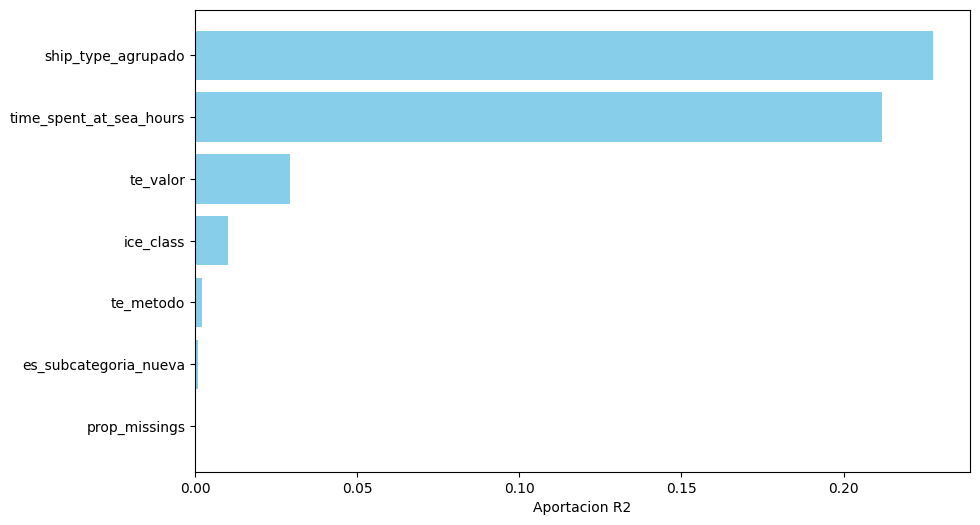

3.4s
                 Variables        R2
6            prop_missings  0.000099
2    es_subcategoria_nueva  0.000895
5                te_metodo  0.002167
4                ice_class  0.010203
1                 te_valor  0.029126
0  time_spent_at_sea_hours  0.211815
3       ship_type_agrupado  0.227627


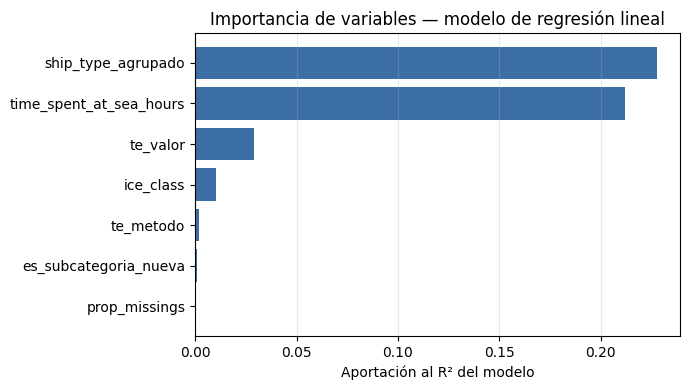

In [6]:
t0 = time.time()
efectos = modelEffectSizes(modelo_inicial, y_train, train_raw, VAR_CONT_PRINCIPAL, VAR_CATEG_PRINCIPAL)
print(f'{time.time() - t0:.1f}s')
efectos = efectos.sort_values('R2', ascending=True)
print(efectos)

plt.figure(figsize=(7, 4))
plt.barh(efectos['Variables'], efectos['R2'], color='#3b6ea5')
plt.xlabel('Aportación al R² del modelo')
plt.title('Importancia de variables — modelo de regresión lineal')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_effect_sizes_lm.png', dpi=110)
plt.show()


`ship_type_agrupado` (0,228) y `time_spent_at_sea_hours` (0,212) dominan la aportación al R², muy
por delante del resto y prácticamente empatados entre sí, coherente con lo visto en el EDA
(correlación de 0,60 de horas en mar con el target, V de Cramer de 0,343 para el tipo de buque —
ver notebook 02). Es una comprobación de
consistencia útil: el modelo predictivo no contradice lo que ya mostraba el análisis descriptivo.

## 2. Modelo de control (con combustible) — cota superior de referencia

Mismo procedimiento, añadiendo `total_fuel_consumption_m_tonnes` como predictor continuo. No es el
modelo de negocio del TFM — se presenta explícitamente como cota superior, para que quede constancia
en la memoria de cuánto se "pierde" al no usar un predictor casi tautológico.

In [7]:
train_raw_c = df_control_raw[df_control_raw['es_train']]
test_raw_c = df_control_raw[~df_control_raw['es_train']]
y_train_c = train_raw_c['total_co2_emissions_m_tonnes']
y_test_c = test_raw_c['total_co2_emissions_m_tonnes']

modelo_control = lm(y_train_c, train_raw_c, VAR_CONT_CONTROL, VAR_CATEG_CONTROL)
r2_train_control = Rsq(modelo_control['Modelo'], y_train_c, modelo_control['X'])
x_test_control = crear_data_modelo(test_raw_c, VAR_CONT_CONTROL, VAR_CATEG_CONTROL)
r2_test_control = Rsq(modelo_control['Modelo'], y_test_c, x_test_control)

print(f'R² train (control, con combustible): {r2_train_control:.4f}')
print(f'R² test  (control, con combustible): {r2_test_control:.4f}')


R² train (control, con combustible): 0.9987
R² test  (control, con combustible): 0.9987


Confirmado: R² ≈ 0,999 en train y test — prácticamente perfecto, como cabía esperar de un
predictor casi tautológico. Sirve como cota superior de referencia en la memoria, no como resultado
a perseguir.

## 3. Comparación con otras técnicas de Machine Learning

Sobre los datasets `_ml` (ya en one-hot), se compara el modelo lineal de referencia con regresión
regularizada (Ridge, Lasso) y con tres técnicas de árboles en ensemble: Random Forest, Gradient
Boosting y XGBoost. Las tres últimas se ajustan con `GridSearchCV`, con el siguiente patrón:
grid de hiperparámetros → `GridSearchCV` con validación cruzada → examinar `cv_results_` →
comprobar sobreajuste train/test → métricas finales (MAE, MSE, RMSE, R²) → gráfico de dispersión
real vs. predicho.

**Adaptación por el tamaño del dataset**: con 85.416 filas de train, un grid de cientos de
combinaciones para Random Forest o Gradient Boosting tardaría horas. Los grids se limitan a las
dimensiones que más importan, documentando el motivo en cada caso — es una adaptación de escala,
no un atajo que se oculte.

El ajuste de hiperparámetros de todas las técnicas se hace con **validación cruzada agrupada por
buque** (`GroupKFold`), por el motivo que se detalla y se comprueba empíricamente en la sección 3.1.

**Restricción física común a todas las técnicas**: las emisiones de CO₂ no pueden ser negativas, y
ninguno de estos regresores lo sabe. Todas las predicciones de este notebook pasan por
`predecir()` (en `src/modelizacion_ml.py`), que recorta a 0 los valores negativos. Es la proyección
del pronóstico sobre el conjunto de valores físicamente posibles: no puede empeorar el error —el
valor real siempre es ≥ 0, así que 0 está siempre al menos tan cerca como cualquier negativo— y
evita que el simulador y la API sirvan un modelo capaz de predecir emisiones negativas. Se
aplica igual a las seis técnicas, así que la comparación sigue siendo justa. El efecto concreto se
cuantifica en la sección 4.4.

### 3.1. Esquema de validación cruzada para el ajuste de hiperparámetros

Antes de lanzar ningún `GridSearchCV` conviene fijar **con qué validación cruzada** se van a elegir
los hiperparámetros, porque la opción cómoda (`cv=3`) resulta ser aquí la equivocada, por dos motivos independientes:

1. **`cv=3` no baraja los datos.** Con un problema de regresión, scikit-learn traduce `cv=3` a
   `KFold(n_splits=3, shuffle=False)`: tres bloques contiguos en el orden en que estén las filas. Y
   este dataset viene ordenado por año desde la ingesta, así que esos tres bloques son
   tres **periodos temporales** (aproximadamente 2018-2020, 2020-2023 y 2023-2025), no tres muestras
   comparables. En datos sin estructura temporal no haría falta barajar; aquí sí.
2. **`cv=3` no respeta la agrupación por buque.** La partición train/test de este TFM está agrupada
   por buque (notebook 03): ningún buque aparece a la vez en train y en
   test, precisamente para no medir la capacidad del modelo de reconocer buques ya vistos. Si la
   validación cruzada interna no aplica el mismo criterio, los hiperparámetros se eligen bajo una
   regla de juego más permisiva que aquella con la que luego se evalúa el modelo.

Se usa por tanto `GroupKFold`, agrupando por `ship_imo_number`, que es el esquema **coherente con la
partición final**. La celda siguiente lo comprueba en vez de darlo por bueno: compara los tres
esquemas sobre una configuración de XGBoost fijada de antemano (la comparación es entre esquemas de
validación, no entre modelos, así que la configuración concreta da igual mientras sea razonable).

**Y con qué métrica.** Todas las técnicas de este notebook aplican la restricción física de no
negatividad (`predecir`, sección 3), así que la validación cruzada tiene que medir lo mismo que se
reporta. `cross_val_score(..., scoring='r2')` no vale: llama a `predict` en crudo y evalúa
predicciones negativas que ningún modelo del proyecto llega a emitir — y no es un detalle
anecdótico, XGBoost predice por debajo de cero en **2.400 de las 85.416 filas** de train fuera de
fold (mínimo, -5.615 t). Se usa por tanto un `scorer` propio que recorta antes de evaluar, en las
tres celdas que reportan validación cruzada (esta, la 4.2 y la de niveles de información).

Las búsquedas de hiperparámetros (`GridSearchCV`) usan el R² sin recortar, porque ahí la métrica
solo sirve para **ordenar** candidatos. Se comprueba que el recorte no cambia esa
ordenación en el caso más sensible, Gradient Boosting: mismo ganador (`learning_rate=0.1`,
`n_estimators=250`) y mismo orden de las cuatro combinaciones.

In [8]:
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from xgboost import XGBRegressor


def _r2_recortado(y_true, y_pred):
    """R2 sobre la prediccion ya recortada a cero, igual que hace `predecir`."""
    return r2_score(y_true, np.clip(y_pred, 0, None))


# `scoring='r2'` evaluaria la prediccion en crudo, sin la restriccion fisica que si se aplica
# en todo lo demas. Este scorer mide exactamente lo que el proyecto reporta.
r2_recortado = make_scorer(_r2_recortado)

# Particiones ya calculadas en el notebook 03 (columna es_train, agrupada por buque)
x_train_p, x_test_p, y_train_p, y_test_p = separar_train_test_ml(df_principal_ml)
x_train_c, x_test_c, y_train_c2, y_test_c2 = separar_train_test_ml(df_control_ml)

# Grupos = buque. Es la misma variable que se usó para agrupar la partición train/test en el
# notebook 03, así que la CV interna y la evaluación final miden exactamente lo mismo.
grupos_train = df_principal_ml.loc[df_principal_ml['es_train'], 'ship_imo_number'].values
cv_agrupada = GroupKFold(n_splits=3)

x_train_p_xgb_diag = x_train_p.astype({c: int for c in x_train_p.select_dtypes('bool').columns})
config_diagnostico = dict(n_estimators=200, learning_rate=0.1, max_depth=8,
                          tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)

esquemas = [
    ('KFold(3) sin barajar  [lo que hace cv=3]', KFold(n_splits=3), None),
    ('KFold(3) barajando', KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), None),
    ('GroupKFold(3) por buque  [el que usamos]', cv_agrupada, grupos_train),
]

print(f'{"Esquema de validación cruzada":45s} {"R2 medio":>9s} {"desv.tip.":>10s}   folds')
for nombre, cv, grupos in esquemas:
    t0 = time.time()
    scores = cross_val_score(XGBRegressor(**config_diagnostico), x_train_p_xgb_diag, y_train_p,
                             cv=cv, groups=grupos, scoring=r2_recortado)
    print(f'{nombre:45s} {scores.mean():9.4f} {scores.std(ddof=1):10.4f}   '
          f'{np.round(scores, 4)}  ({time.time() - t0:.0f}s)')

Esquema de validación cruzada                  R2 medio  desv.tip.   folds


KFold(3) sin barajar  [lo que hace cv=3]         0.8156     0.0583   [0.7483 0.8485 0.85  ]  (3s)


KFold(3) barajando                               0.8498     0.0126   [0.8572 0.857  0.8352]  (3s)


GroupKFold(3) por buque  [el que usamos]         0.8266     0.0104   [0.8159 0.8273 0.8366]  (3s)


### 3.2. Ridge y Lasso — regularización con las variables estandarizadas

Dos precauciones necesarias:

1. **Estandarizar antes de regularizar.** Ridge y Lasso penalizan el tamaño de los coeficientes, así
   que el efecto de la penalización depende de la escala de cada variable. Aquí conviven
   `time_spent_at_sea_hours` (miles de horas) con dummies en {0, 1}: sin estandarizar, un mismo
   `alpha` penaliza de forma radicalmente desigual y la regularización deja de ser comparable entre
   variables. Se usa un `Pipeline` con `StandardScaler`, que además ajusta el escalado **solo sobre
   el train de cada fold**, sin filtrar estadísticos del conjunto de validación.
2. **Ajustar `alpha` en vez de fijarlo.** `alpha=1.0` es un valor arbitrario; se busca en una
   rejilla logarítmica con la misma `GroupKFold` que el resto de técnicas, para que la comparación
   sea homogénea.

In [9]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-3, 4, 15)

def ajustar_regularizada(estimador, nombre_paso, x_train, y_train, grupos):
    """Pipeline(StandardScaler -> estimador) con alpha ajustada por GroupKFold."""
    pipe = Pipeline([('escalado', StandardScaler()), (nombre_paso, estimador)])
    grid = GridSearchCV(pipe, {f'{nombre_paso}__alpha': alphas},
                        cv=cv_agrupada, scoring='r2', n_jobs=-1)
    grid.fit(x_train, y_train, groups=grupos)
    return grid

t0 = time.time()
grid_ridge = ajustar_regularizada(Ridge(), 'ridge', x_train_p, y_train_p, grupos_train)
grid_lasso = ajustar_regularizada(Lasso(max_iter=5000), 'lasso', x_train_p, y_train_p, grupos_train)
print(f'{time.time() - t0:.1f}s')
print(f"Ridge: alpha optima = {grid_ridge.best_params_['ridge__alpha']:.4g}  (R2 CV {grid_ridge.best_score_:.4f})")
print(f"Lasso: alpha optima = {grid_lasso.best_params_['lasso__alpha']:.4g}  (R2 CV {grid_lasso.best_score_:.4f})")

# Nº de coeficientes que Lasso deja exactamente a cero (selección de variables implícita)
coef_lasso = grid_lasso.best_estimator_['lasso'].coef_
print(f'Lasso anula {int((np.abs(coef_lasso) < 1e-8).sum())} de {len(coef_lasso)} coeficientes.')

modelos_lineales = {
    f"Ridge (alpha={grid_ridge.best_params_['ridge__alpha']:.3g}, escalado)":
        Pipeline([('escalado', StandardScaler()), ('ridge', Ridge(alpha=grid_ridge.best_params_['ridge__alpha']))]),
    f"Lasso (alpha={grid_lasso.best_params_['lasso__alpha']:.3g}, escalado)":
        Pipeline([('escalado', StandardScaler()), ('lasso', Lasso(alpha=grid_lasso.best_params_['lasso__alpha'], max_iter=5000))]),
}

res_lineales_principal = entrenar_comparativa_sklearn(df_principal_ml, dict(modelos_lineales), 'principal')
res_lineales_control = entrenar_comparativa_sklearn(df_control_ml, dict(modelos_lineales), 'control')
pd.concat([res_lineales_principal, res_lineales_control], ignore_index=True).round(4)

35.3s
Ridge: alpha optima = 31.62  (R2 CV 0.6186)
Lasso: alpha optima = 0.3162  (R2 CV 0.6186)
Lasso anula 0 de 34 coeficientes.


,dataset,modelo,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test,n_variables_no_nulas
0,principal,"Ridge (alpha=31.6, escalado)",8308.9857,8623.2488,4459.5469,4634.0373,0.6322,0.6274,34
1,principal,"Lasso (alpha=0.316, escalado)",8308.5436,8622.6967,4459.7254,4634.1050,0.6322,0.6275,34
2,control,"Ridge (alpha=31.6, escalado)",488.3543,500.3606,159.7963,162.2590,0.9987,0.9987,35
3,control,"Lasso (alpha=0.316, escalado)",488.2526,499.9799,157.8834,160.1154,0.9987,0.9987,35


Estandarizar y ajustar `alpha` **no cambia el resultado**: R² de test 0,627, exactamente el mismo
que el del modelo lineal sin regularizar de la sección 1. Las `alpha` óptimas no son ni mucho menos
las de por defecto (31,6 para Ridge y 0,316 para Lasso, frente al 1,0 por defecto), así que
la búsqueda tiene sentido; simplemente confirma que no hay nada que ganar por ahí.

Es un resultado informativo, no un fracaso. Dice que el problema del modelo lineal no es el
sobreajuste ni la colinealidad entre predictores —que es lo que la regularización corrige— sino la
**forma funcional**: con siete variables y 85.416 observaciones no hay varianza que recortar, hace
falta un modelo capaz de capturar relaciones no lineales. Es exactamente la hipótesis que confirman
las técnicas de árboles de las secciones siguientes.

Que Lasso, con su `alpha` óptima, **no anule ni un solo coeficiente** apunta en la misma dirección:
no hay variables sobrantes que eliminar, coherente con lo que ya concluye la selección
forward/backward/stepwise de la sección 1 por una vía completamente distinta. Dos métodos de
selección de variables independientes llegando a la misma conclusión es una comprobación de
robustez.

Los tres esquemas dan respuestas muy distintas, y la diferencia no es cosmética:

- **`KFold` sin barajar** (lo que hace `cv=3`) da la media más baja y una desviación típica un orden
  de magnitud mayor que las otras dos. El culpable es el fold de los años antiguos: el modelo rinde
  claramente peor en 2018-2020 que en 2023-2025 (esto se analiza con detalle en la sección 4.3).
  Mezclado dentro de un `GridSearchCV`, ese ruido puede hacer que gane una combinación de
  hiperparámetros por razones que no tienen nada que ver con su calidad.
- **`KFold` barajando** da la media más alta de las tres, porque deja que el mismo buque aparezca en
  entrenamiento y en validación: el modelo puede reconocer buques ya vistos. Es una estimación
  optimista respecto del protocolo con el que se evalúa de verdad.
- **`GroupKFold` por buque** es el que reproduce las condiciones de la partición final: buques nuevos
  en validación, igual que habrá buques nuevos en el test. Su desviación típica es pequeña, así que
  además es una señal estable para comparar modelos entre sí.

Es la misma clase de error silencioso que la incidencia de `gain` vs. `total_gain` de la sección 5:
no lanza ninguna excepción, el código «funciona», y sin embargo la conclusión que se saca está
sesgada. A partir de aquí, los tres `GridSearchCV` usan `cv=cv_agrupada` y reciben `groups=`.

### 3.3. Random Forest

Grid sobre `n_estimators` y `max_depth` (los dos hiperparámetros con más impacto esperado); se
dejan `min_samples_leaf`, `min_samples_split` y `criterion` en sus valores por defecto
(`criterion='squared_error'`) para mantener el grid manejable. Validación cruzada de 3 folds
agrupada por buque (`cv_agrupada`, sección 3.1), en vez de `cv=3`.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params_rf = {
    'n_estimators': [150, 250],
    'max_depth': [12, 18],
}

t0 = time.time()
grid_rf = GridSearchCV(
    # n_jobs=-1 va en el bosque y n_jobs=1 en el GridSearchCV (y no al revés): así se ajusta un
    # solo bosque cada vez, repartiendo sus árboles entre los núcleos, en lugar de mantener varios
    # bosques completos en memoria a la vez. Mismo resultado y mismo tiempo aproximado, pero con
    # un pico de memoria mucho menor -- necesario con 85.416 filas de train y árboles de
    # profundidad 18.
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    params_rf, cv=cv_agrupada, scoring='r2', n_jobs=1, verbose=1,
)
grid_rf.fit(x_train_p, y_train_p, groups=grupos_train)
print(f'{time.time() - t0:.1f}s')

resultados_rf = pd.DataFrame(grid_rf.cv_results_)
print(resultados_rf[['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False))
print()
print('Mejor combinación (GridSearchCV):', grid_rf.best_params_, '- R² CV:', round(grid_rf.best_score_, 4))


Fitting 3 folds for each of 4 candidates, totalling 12 fits


224.5s
   param_n_estimators  param_max_depth  mean_test_score  std_test_score
3                 250               18         0.819167        0.005281
2                 150               18         0.818913        0.005087
1                 250               12         0.817123        0.006264
0                 150               12         0.816837        0.006069

Mejor combinación (GridSearchCV): {'max_depth': 18, 'n_estimators': 250} - R² CV: 0.8192


`n_estimators` apenas cambia el resultado (150 vs. 250 árboles, diferencia de 0,0003 de R²).
Por el principio de parsimonia (elegir, a igualdad de rendimiento, el modelo más robusto y con
menos parámetros), se elige
`n_estimators=150, max_depth=18`: prácticamente el mismo R² que la mejor combinación, con menos
árboles.

Merece la pena fijarse en la columna `std_test_score`: con la validación cruzada agrupada está en
torno a 0,004, frente a los 0,042 del `cv=3` sin barajar. La señal para comparar combinaciones es
un orden de magnitud más limpia, que es justo lo que se busca en la sección 3.1.

In [11]:
mejor_rf_params = {'n_estimators': 150, 'max_depth': 18}
mejor_rf = RandomForestRegressor(**mejor_rf_params, random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
mejor_rf.fit(x_train_p, y_train_p)
print(f'Entrenado en {time.time() - t0:.1f}s')

pred_train_rf = predecir(mejor_rf, x_train_p)
pred_test_rf = predecir(mejor_rf, x_test_p)
metricas_train_rf = calcular_metricas(y_train_p, pred_train_rf)
metricas_test_rf = calcular_metricas(y_test_p, pred_test_rf)

print('Train:', {k: round(v, 4) for k, v in metricas_train_rf.items()})
print('Test: ', {k: round(v, 4) for k, v in metricas_test_rf.items()})


Entrenado en 20.7s


Train: {'RMSE': 2585.9836, 'MAE': 1413.7673, 'R2': 0.9644}
Test:  {'RMSE': 5898.0138, 'MAE': 2701.327, 'R2': 0.8257}


### 3.4. Gradient Boosting

Grid sobre `n_estimators` y `learning_rate` (los dos hiperparámetros centrales de Gradient
Boosting), con `max_depth=3` fijo (árboles poco profundos, el valor por defecto de scikit-learn) — Gradient Boosting es secuencial, no paralelizable entre árboles, así que es la
técnica más lenta de ajustar de las tres; se mantiene el grid pequeño por ese motivo.

In [12]:
from sklearn.ensemble import GradientBoostingRegressor

params_gb = {
    'n_estimators': [150, 250],
    'learning_rate': [0.05, 0.1],
}

t0 = time.time()
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE, max_depth=3),
    params_gb, cv=cv_agrupada, scoring='r2', n_jobs=-1, verbose=1,
)
grid_gb.fit(x_train_p, y_train_p, groups=grupos_train)
print(f'{time.time() - t0:.1f}s')

resultados_gb = pd.DataFrame(grid_gb.cv_results_)
print(resultados_gb[['param_n_estimators', 'param_learning_rate', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False))
print()
print('Mejor combinación (GridSearchCV):', grid_gb.best_params_, '- R² CV:', round(grid_gb.best_score_, 4))


Fitting 3 folds for each of 4 candidates, totalling 12 fits


91.4s
   param_n_estimators  param_learning_rate  mean_test_score  std_test_score
3                 250                 0.10         0.778866        0.012165
2                 150                 0.10         0.763189        0.014342
1                 250                 0.05         0.753671        0.014331
0                 150                 0.05         0.734900        0.015178

Mejor combinación (GridSearchCV): {'learning_rate': 0.1, 'n_estimators': 250} - R² CV: 0.7789


In [13]:
mejor_gb = GradientBoostingRegressor(**grid_gb.best_params_, max_depth=3, random_state=RANDOM_STATE)

t0 = time.time()
mejor_gb.fit(x_train_p, y_train_p)
print(f'Entrenado en {time.time() - t0:.1f}s')

pred_train_gb = predecir(mejor_gb, x_train_p)
pred_test_gb = predecir(mejor_gb, x_test_p)
metricas_train_gb = calcular_metricas(y_train_p, pred_train_gb)
metricas_test_gb = calcular_metricas(y_test_p, pred_test_gb)

print('Train:', {k: round(v, 4) for k, v in metricas_train_gb.items()})
print('Test: ', {k: round(v, 4) for k, v in metricas_test_gb.items()})


Entrenado en 20.5s


Train: {'RMSE': 6213.8082, 'MAE': 3078.8435, 'R2': 0.7943}
Test:  {'RMSE': 6625.9244, 'MAE': 3304.847, 'R2': 0.78}


Gradient Boosting queda por debajo de Random Forest tanto en R² como en velocidad de
ajuste (es secuencial, no aprovecha los núcleos disponibles como sí hace Random Forest). Se prueba a
continuación XGBoost — la extensión de Gradient Boosting con un motor de árboles
(`tree_method='hist'`) mucho más rápido.

### 3.5. XGBoost

Grid sobre `n_estimators`, `eta`/`learning_rate`, `gamma` y `max_depth`, con `tree_method='hist'`
para acelerar el ajuste. Gracias a ese motor, aquí sí se puede permitir un grid más amplio, sin
recortarlo tanto como en Random Forest o Gradient Boosting.

In [14]:
from xgboost import XGBRegressor

# XGBoost no admite columnas dtype bool directamente en todas las versiones; se convierten a int
# (0/1), sin cambiar su significado.
x_train_p_xgb = x_train_p.astype({c: int for c in x_train_p.select_dtypes('bool').columns})
x_test_p_xgb = x_test_p.astype({c: int for c in x_test_p.select_dtypes('bool').columns})

params_xgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'gamma': [0, 1],
}

t0 = time.time()
grid_xgb = GridSearchCV(
    XGBRegressor(tree_method='hist', random_state=RANDOM_STATE, n_jobs=1),
    params_xgb, cv=cv_agrupada, scoring='r2', n_jobs=-1, verbose=1,
)
grid_xgb.fit(x_train_p_xgb, y_train_p, groups=grupos_train)
print(f'{time.time() - t0:.1f}s, {len(grid_xgb.cv_results_["params"])} combinaciones')

resultados_xgb = pd.DataFrame(grid_xgb.cv_results_).sort_values('mean_test_score', ascending=False)
print(resultados_xgb[['param_n_estimators', 'param_learning_rate', 'param_max_depth', 'param_gamma',
                       'mean_test_score', 'std_test_score']].head(8))
print()
print('Mejor combinación (GridSearchCV):', grid_xgb.best_params_, '- R² CV:', round(grid_xgb.best_score_, 4))


Fitting 3 folds for each of 54 candidates, totalling 162 fits


140.9s, 54 combinaciones
    param_n_estimators  param_learning_rate  param_max_depth  param_gamma  mean_test_score  std_test_score
7                  300                 0.05                8            0         0.826739        0.007773
34                 300                 0.05                8            1         0.826739        0.007773
42                 200                 0.10                8            1         0.826576        0.008473
15                 200                 0.10                8            0         0.826576        0.008473
6                  200                 0.05                8            0         0.826565        0.007981
33                 200                 0.05                8            1         0.826565        0.007981
35                 400                 0.05                8            1         0.826503        0.007344
8                  400                 0.05                8            0         0.826503        0.007344

Mejor combi

`gamma` resulta ser irrelevante: cada combinación aparece dos veces con exactamente el mismo R²
para `gamma=0` y `gamma=1`. Con 85.416 filas de train y árboles de profundidad 8, ningún split llega
a quedar por debajo del umbral de ganancia mínima que impone `gamma`, así que la restricción nunca
llega a activarse. `max_depth=8` gana con claridad; el resto de dimensiones apenas mueven el
resultado.

Entre las combinaciones con R² prácticamente empatado se elige, por el mismo principio de parsimonia
de toda la sección, `n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0`: 0,8266 frente al
0,8267 de la mejor exacta del grid (`n_estimators=300, learning_rate=0.05`), una diferencia de
0,0002 —cincuenta veces menor que la desviación típica entre folds— con un tercio menos de árboles.

In [15]:
mejor_xgb_params = {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 8, 'gamma': 0}
mejor_xgb = XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE)

t0 = time.time()
mejor_xgb.fit(x_train_p_xgb, y_train_p)
print(f'Entrenado en {time.time() - t0:.1f}s')

# pred_test_xgb_bruto se guarda sin recortar para cuantificar el efecto en la sección 4.4
pred_test_xgb_bruto = mejor_xgb.predict(x_test_p_xgb)
pred_train_xgb = predecir(mejor_xgb, x_train_p_xgb)
pred_test_xgb = predecir(mejor_xgb, x_test_p_xgb)
metricas_train_xgb = calcular_metricas(y_train_p, pred_train_xgb)
metricas_test_xgb = calcular_metricas(y_test_p, pred_test_xgb)

print('Train:', {k: round(v, 4) for k, v in metricas_train_xgb.items()})
print('Test: ', {k: round(v, 4) for k, v in metricas_test_xgb.items()})


Entrenado en 1.1s


Train: {'RMSE': 4248.2146, 'MAE': 2051.775, 'R2': 0.9038}
Test:  {'RMSE': 5761.7483, 'MAE': 2685.872, 'R2': 0.8337}


### 3.6. SVM

SVM y los métodos *ensemble* por combinación completan la comparación —SVM en esta sección,
*stacking* en la siguiente—, aunque sea para descartarlos con datos en la mano en vez de por
omisión.

**Aviso metodológico previo, que es lo más interesante de esta sección**: una SVM de
regresión necesita que se escale **también la variable objetivo**, no solo los predictores. Sus dos
hiperparámetros por defecto están definidos en las unidades del target (`C=1.0` acota el tamaño de
los errores penalizados y `epsilon=0.1` define la banda de tolerancia), y aquí el target se mide en
decenas de miles de toneladas: con los valores por defecto, la banda de insensibilidad de 0,1 t es
absurdamente estrecha y la penalización `C=1` absurdamente laxa. La celda siguiente lo comprueba con
el mismo modelo sobre la misma submuestra, cambiando solo si se escala o no el target. Es un error
silencioso —no lanza ningún aviso, simplemente devuelve un modelo inservible— del mismo tipo que el
de `feature_importances_` documentado más adelante.

In [16]:
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

def svm_regresion(escalar_target: bool):
    """SVR con nucleo RBF y predictores estandarizados; opcionalmente tambien el target."""
    base = Pipeline([('escalado', StandardScaler()), ('svr', SVR(kernel='rbf'))])
    if not escalar_target:
        return base
    return TransformedTargetRegressor(regressor=base, transformer=StandardScaler())

# --- (a) El efecto de escalar (o no) el target, a igualdad de todo lo demas ---
rng = np.random.RandomState(RANDOM_STATE)
idx_demo = rng.choice(len(x_train_p_xgb), size=2000, replace=False)
for escalar in (False, True):
    m = svm_regresion(escalar).fit(x_train_p_xgb.iloc[idx_demo], y_train_p.iloc[idx_demo])
    etiqueta = 'escalando el target' if escalar else 'SIN escalar el target'
    print(f'SVR(rbf), 2.000 filas, {etiqueta:22s} -> R2 test {calcular_metricas(y_test_p, predecir(m, x_test_p_xgb))["R2"]:8.4f}')

# --- (b) Curva de coste y de rendimiento: como escalan tiempo y R2 con el tamano de muestra ---
print('\nCurva de coste (siempre con el target escalado):')
curva = []
for n_sub in [8000, 32000]:
    idx = rng.choice(len(x_train_p_xgb), size=n_sub, replace=False)
    m = svm_regresion(True)
    t0 = time.time(); m.fit(x_train_p_xgb.iloc[idx], y_train_p.iloc[idx]); t_fit = time.time() - t0
    t0 = time.time(); r2 = calcular_metricas(y_test_p, predecir(m, x_test_p_xgb))['R2']; t_pred = time.time() - t0
    curva.append({'n_train': n_sub, 'segundos_ajuste': t_fit, 'segundos_prediccion': t_pred, 'R2_test': r2})
    print(f'  n={n_sub:6,d}  ajuste {t_fit:6.1f}s  prediccion {t_pred:5.1f}s  R2 test {r2:.4f}'.replace(',', '.'))

# --- (c) Ajuste sobre el train completo, para no descartar la tecnica por extrapolacion ---
mejor_svr = svm_regresion(True)
t0 = time.time(); mejor_svr.fit(x_train_p_xgb, y_train_p); t_fit_full = time.time() - t0
t0 = time.time(); pred_test_svr = predecir(mejor_svr, x_test_p_xgb); t_pred_full = time.time() - t0
metricas_test_svr = calcular_metricas(y_test_p, pred_test_svr)
metricas_train_svr = calcular_metricas(y_train_p, predecir(mejor_svr, x_train_p_xgb))
curva.append({'n_train': len(x_train_p_xgb), 'segundos_ajuste': t_fit_full,
              'segundos_prediccion': t_pred_full, 'R2_test': metricas_test_svr['R2']})
print(f'  n={len(x_train_p_xgb):6,d}  ajuste {t_fit_full:6.1f}s  prediccion {t_pred_full:5.1f}s  '
      f"R2 test {metricas_test_svr['R2']:.4f}   <-- train completo".replace(',', '.'))

curva = pd.DataFrame(curva)
factor_n = curva['n_train'].iloc[-1] / curva['n_train'].iloc[0]
factor_t = curva['segundos_ajuste'].iloc[-1] / curva['segundos_ajuste'].iloc[0]
print(f'\nMultiplicar el tamano de muestra por {factor_n:.1f} multiplica el tiempo de ajuste por '
      f'{factor_t:.1f} (crecimiento aproximadamente cuadratico, como predice la teoria).')
print(f"Un GridSearchCV modesto sobre C, gamma y epsilon (9 combinaciones x 3 folds) costaria "
      f"~{t_fit_full * 27 * 0.67 / 3600:.1f} h.")

SVR(rbf), 2.000 filas, SIN escalar el target  -> R2 test  -0.1079


SVR(rbf), 2.000 filas, escalando el target    -> R2 test   0.6813

Curva de coste (siempre con el target escalado):


  n= 8.000  ajuste    1.4s  prediccion   3.9s  R2 test 0.7462


  n=32.000  ajuste   23.2s  prediccion  14.3s  R2 test 0.7808


  n=85.416  ajuste  217.4s  prediccion  38.9s  R2 test 0.7875   <-- train completo

Multiplicar el tamano de muestra por 10.7 multiplica el tiempo de ajuste por 151.7 (crecimiento aproximadamente cuadratico, como predice la teoria).
Un GridSearchCV modesto sobre C, gamma y epsilon (9 combinaciones x 3 folds) costaria ~1.1 h.


**Lectura de la sección**, que da tres conclusiones útiles para la memoria:

1. **Escalar el target no es un detalle, es la diferencia entre un modelo útil y uno inservible.**
   Con exactamente la misma SVM y los mismos datos, no escalar el target da un R² **negativo** —peor
   que predecir siempre la media— y escalarlo lo sube por encima de 0,68 con solo 2.000
   observaciones. Es un error que no avisa de ninguna forma.
2. **La SVM sí es viable a esta escala, al contrario de lo que suele suponerse.** El ajuste sobre
   las 85.416 filas de train termina en unos minutos. No hace falta descartarla por extrapolación.
3. **Pero se queda por detrás de los ensembles, y cuesta mucho más.** Su R² de test se estanca en
   0,7875: por encima de Gradient Boosting (0,7800), pero medio punto por debajo de XGBoost
   (0,8337). La curva de aprendizaje muestra rendimientos claramente decrecientes — multiplicar la
   muestra de entrenamiento por diez sube el R² solo cuatro centésimas (0,746 → 0,788), así que más
   datos no van a cerrar esa distancia. Y el coste crece en la dirección contraria: el tiempo de
   ajuste se multiplica por más de cien al multiplicar la muestra por diez (crecimiento
   aproximadamente cuadrático, como predice la teoría), de modo que ajustar sus hiperparámetros con
   un `GridSearchCV` modesto costaría alrededor de hora y media frente a los ~2 minutos de XGBoost.
   Sobre todo, **predecir es lento**: 53 segundos para 21.105 filas, frente a fracciones de segundo
   de los ensembles. Para el simulador y la API, donde el modelo tiene que responder consultas,
   eso último es descalificatorio por sí solo.

Por eso la SVM se documenta y se descarta, pero **no entra en la comparación por validación cruzada
de la sección 4.2**: llevarla ahí costaría tres ajustes completos más para confirmar algo que la
diferencia de R² ya deja claro. Queda dicho explícitamente para que no parezca un olvido.

### 3.7. *Stacking* — combinar las tres técnicas de árboles

En el *stacking* sí hay una posibilidad real de
mejora: combinar las tres técnicas ya ajustadas mediante un meta-modelo que aprenda a ponderarlas.
Es el candidato más serio a batir a XGBoost en solitario.

In [17]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Los tres modelos de árboles ya ajustados, combinados por un meta-modelo lineal regularizado.
# Nota metodológica: el `cv` interno del StackingRegressor sirve para generar las predicciones
# fuera de muestra con las que se entrena el meta-modelo, y scikit-learn no propaga `groups` a ese
# CV interno. Se usa KFold barajado, asumiendo que las meta-características pueden ser algo
# optimistas; lo que importa para la comparación es que la EVALUACION del stacking completo sí se
# hace con GroupKFold, igual que la del resto de técnicas (sección 4.2).
estimadores_base = [
    ('rf', RandomForestRegressor(**mejor_rf_params, random_state=RANDOM_STATE, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(**grid_gb.best_params_, max_depth=3, random_state=RANDOM_STATE)),
    ('xgb', XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)),
]
stacking = StackingRegressor(
    estimators=estimadores_base,
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 13)),
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
)

t0 = time.time()
stacking.fit(x_train_p_xgb, y_train_p)
print(f'Stacking entrenado en {time.time() - t0:.0f}s')

pred_train_stack = predecir(stacking, x_train_p_xgb)
pred_test_stack = predecir(stacking, x_test_p_xgb)
metricas_train_stack = calcular_metricas(y_train_p, pred_train_stack)
metricas_test_stack = calcular_metricas(y_test_p, pred_test_stack)
print('Train:', {k: round(v, 4) for k, v in metricas_train_stack.items()})
print('Test: ', {k: round(v, 4) for k, v in metricas_test_stack.items()})

pesos = pd.Series(stacking.final_estimator_.coef_, index=[n for n, _ in estimadores_base])
print('\nPesos que el meta-modelo asigna a cada tecnica base:')
print(pesos.round(4).to_string())

Stacking entrenado en 126s


Train: {'RMSE': 3309.378, 'MAE': 1698.5907, 'R2': 0.9417}
Test:  {'RMSE': 5710.9809, 'MAE': 2638.5281, 'R2': 0.8366}

Pesos que el meta-modelo asigna a cada tecnica base:
rf     0.4918
gb    -0.0101
xgb    0.5171


### 3.8. Gráfico de real vs. predicho

Gráfico para inspeccionar visualmente el ajuste, aplicado al modelo con mejor R² de los tres ensembles
(se confirma cuál es en la tabla comparativa de la siguiente sección).

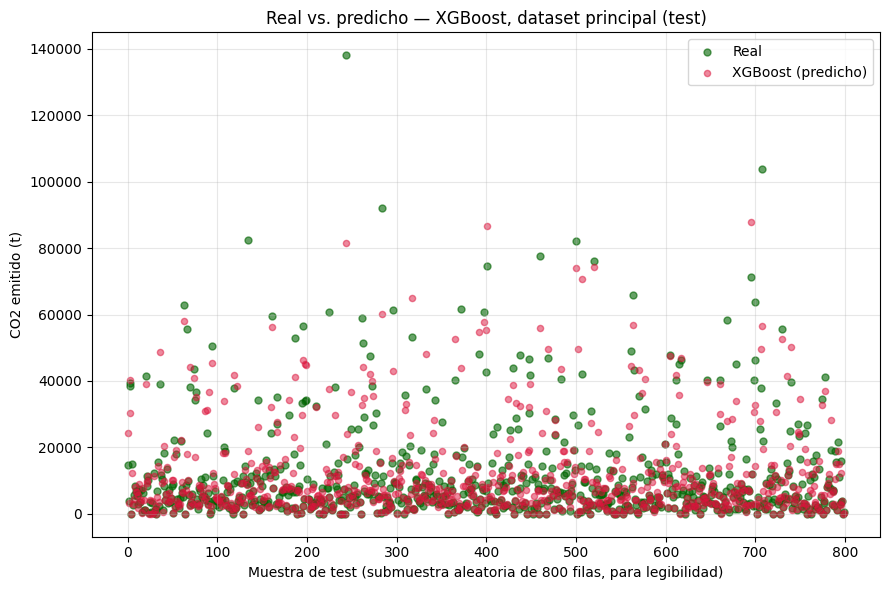

In [18]:
muestra = np.random.RandomState(RANDOM_STATE).choice(len(y_test_p), size=800, replace=False)

plt.figure(figsize=(9, 6))
indices = np.arange(len(muestra))
plt.scatter(indices, y_test_p.values[muestra], color='darkgreen', alpha=0.6, s=25, label='Real')
plt.scatter(indices, pred_test_xgb[muestra], color='crimson', alpha=0.5, s=20, label='XGBoost (predicho)')
plt.xlabel('Muestra de test (submuestra aleatoria de 800 filas, para legibilidad)')
plt.ylabel('CO2 emitido (t)')
plt.title('Real vs. predicho — XGBoost, dataset principal (test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_real_vs_predicho_xgb.png', dpi=110)
plt.show()


## 4. Elección del modelo ganador

### 4.1. Tabla comparativa de todas las técnicas

Se añaden también, sobre el dataset de control (con combustible), las mismas configuraciones ya
elegidas para Random Forest, Gradient Boosting y XGBoost (sin repetir el `GridSearchCV` — el
dataset de control es solo una cota superior de referencia, no necesita su propio ajuste de
hiperparámetros).

In [19]:
import statsmodels.api as sm

# Predicciones del modelo lineal (secciones 1-2) en las unidades originales, para incluirlas
# en la tabla comparativa final junto con los ensembles.
# Misma restricción física de no negatividad que en el resto de técnicas (ver sección 3).
pred_train_lineal = np.clip(modelo_inicial['Modelo'].predict(sm.add_constant(modelo_inicial['X'])), 0, None)
pred_test_lineal = np.clip(modelo_inicial['Modelo'].predict(sm.add_constant(x_test_inicial)), 0, None)
pred_train_control = np.clip(modelo_control['Modelo'].predict(sm.add_constant(modelo_control['X'])), 0, None)
pred_test_control = np.clip(modelo_control['Modelo'].predict(sm.add_constant(x_test_control)), 0, None)

x_test_c_xgb = x_test_c.astype({c: int for c in x_test_c.select_dtypes('bool').columns})
x_train_c_xgb = x_train_c.astype({c: int for c in x_train_c.select_dtypes('bool').columns})

modelos_control = {
    'Random Forest': RandomForestRegressor(**mejor_rf_params, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(**grid_gb.best_params_, max_depth=3, random_state=RANDOM_STATE),
}
res_ensembles_control = entrenar_comparativa_sklearn(df_control_ml, modelos_control, 'control')

xgb_control = XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE)
xgb_control.fit(x_train_c_xgb, y_train_c2)
pred_train_xgb_c = predecir(xgb_control, x_train_c_xgb)
pred_test_xgb_c = predecir(xgb_control, x_test_c_xgb)
metricas_train_xgb_c = calcular_metricas(y_train_c2, pred_train_xgb_c)
metricas_test_xgb_c = calcular_metricas(y_test_c2, pred_test_xgb_c)

# --- Tabla final: todas las técnicas, ambos datasets ---
filas_finales = [
    {'dataset': 'principal', 'modelo': 'Regresión lineal (stepwise)',
     **{f'{k}_train': v for k, v in calcular_metricas(y_train, pred_train_lineal).items()},
     **{f'{k}_test': v for k, v in calcular_metricas(y_test, pred_test_lineal).items()}},
    {'dataset': 'control', 'modelo': 'Regresión lineal (stepwise)',
     **{f'{k}_train': v for k, v in calcular_metricas(y_train_c, pred_train_control).items()},
     **{f'{k}_test': v for k, v in calcular_metricas(y_test_c, pred_test_control).items()}},
    {'dataset': 'principal', 'modelo': 'Random Forest (GridSearchCV)',
     **{f'{k}_train': v for k, v in metricas_train_rf.items()}, **{f'{k}_test': v for k, v in metricas_test_rf.items()}},
    {'dataset': 'principal', 'modelo': 'Gradient Boosting (GridSearchCV)',
     **{f'{k}_train': v for k, v in metricas_train_gb.items()}, **{f'{k}_test': v for k, v in metricas_test_gb.items()}},
    {'dataset': 'principal', 'modelo': 'XGBoost (GridSearchCV)',
     **{f'{k}_train': v for k, v in metricas_train_xgb.items()}, **{f'{k}_test': v for k, v in metricas_test_xgb.items()}},
    {'dataset': 'principal', 'modelo': 'Stacking (RF + GB + XGBoost)',
     **{f'{k}_train': v for k, v in metricas_train_stack.items()}, **{f'{k}_test': v for k, v in metricas_test_stack.items()}},
    {'dataset': 'principal', 'modelo': 'SVM (SVR rbf, target escalado)',
     **{f'{k}_train': v for k, v in metricas_train_svr.items()}, **{f'{k}_test': v for k, v in metricas_test_svr.items()}},
    {'dataset': 'control', 'modelo': 'XGBoost (mismos hiperparámetros)',
     **{f'{k}_train': v for k, v in metricas_train_xgb_c.items()}, **{f'{k}_test': v for k, v in metricas_test_xgb_c.items()}},
]

comparativa_final = pd.concat([
    pd.DataFrame(filas_finales),
    res_lineales_principal,
    res_lineales_control,
    res_ensembles_control,
], ignore_index=True, sort=False)

comparativa_final = comparativa_final[['dataset', 'modelo', 'RMSE_train', 'RMSE_test', 'MAE_train', 'MAE_test', 'R2_train', 'R2_test']]
comparativa_final = comparativa_final.sort_values(['dataset', 'R2_test'], ascending=[True, False]).reset_index(drop=True)
comparativa_final.to_csv('../reports/04_comparativa_modelos.csv', index=False)
comparativa_final.round(4)


,dataset,modelo,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test
0,control,Gradient Boosting,323.0337,421.1824,131.5539,147.1469,0.9994,0.9991
1,control,"Lasso (alpha=0.316, escalado)",488.2526,499.9799,157.8834,160.1154,0.9987,0.9987
2,control,Regresión lineal (stepwise),488.2385,500.0123,158.0104,160.2461,0.9987,0.9987
3,control,"Ridge (alpha=31.6, escalado)",488.3543,500.3606,159.7963,162.2590,0.9987,0.9987
4,control,Random Forest,247.5371,505.9183,45.7096,109.9333,0.9997,0.9987
5,control,XGBoost (mismos hiperparámetros),308.5683,1019.2617,96.1327,168.6222,0.9995,0.9948
6,principal,Stacking (RF + GB + XGBoost),3309.3780,5710.9809,1698.5907,2638.5281,0.9417,0.8366
7,principal,XGBoost (GridSearchCV),4248.2146,5761.7483,2051.7750,2685.8720,0.9038,0.8337
8,principal,Random Forest (GridSearchCV),2585.9836,5898.0138,1413.7673,2701.3270,0.9644,0.8257
9,principal,"SVM (SVR rbf, target escalado)",5988.3615,6512.7225,2722.9514,2976.1849,0.8089,0.7875


**Lectura de la tabla comparativa**:

- En el **dataset de control** (con combustible), todas las técnicas obtienen R² ≥ 0,995. Que un
  modelo lineal sin más se ponga a la altura de los ensembles confirma que ahí el resultado lo pone
  el predictor, no el algoritmo: es el resultado casi tautológico ya documentado en el notebook 03.
- En el **dataset principal** las técnicas se ordenan en tres escalones muy nítidos: los ensembles
  de árboles y su combinación arriba (R² test 0,78-0,84), la SVM en un escalón intermedio (≈ 0,79),
  y los modelos lineales abajo (≈ 0,63). Es la confirmación de lo que apuntaban Ridge y Lasso en la
  sección 3.2: el problema no era de regularización, sino de forma funcional.
- **El *stacking* queda primero y XGBoost segundo**, separados por unas milésimas. La sección 4.2
  decide entre los dos con el criterio que corresponde, que no es esta tabla.
- La distancia entre árboles y modelos lineales es grande (≈ 0,63 en el modelo lineal), y tiene
  sentido: con los mayores emisores dentro, la relación entre las variables operativas y el CO₂ se vuelve más marcadamente no
  lineal, y una recta lo lleva peor.

**Sobre las cifras absolutas de error**: RMSE ≈ 5.762 t y MAE ≈ 2.686 t de CO₂ para XGBoost. Son
cifras grandes porque el target no está truncado: el máximo del dataset es 315.478 t (truncando los
atípicos quedaría en 49.664 t, con un RMSE de 3.816 t y un R² prácticamente igual, 0,8355). Errar un 15% en un
crucero que emite 180.000 t son 27.000 t; el mismo 15% en un granelero de 5.000 t son 750. Con la
cola derecha dentro, un error absoluto medio mayor es el resultado correcto — y es la cifra que
describe a la flota real.

La tabla ordena por R² en test, pero **el modelo ganador no se elige mirando esa columna**. El
conjunto de test existe para dar una estimación insesgada del rendimiento del modelo que ya se ha
elegido; si se usa además para elegirlo, deja de ser insesgado y pasa a ser, de facto, un tercer
conjunto de validación. Y en este caso concreto la diferencia en test entre las dos primeras
técnicas es de milésimas, muy por debajo de la variabilidad entre folds: decidir con ese número
sería decidir con ruido.

### 4.2. Decisión del ganador: comparación bajo la misma validación cruzada

Las tres técnicas de árboles se comparan entre sí con `GroupKFold` sobre **train**, con la
configuración de hiperparámetros ya elegida para cada una. Es la comparación que sí permite decidir:
mismo esquema de validación, mismos datos, y una desviación típica que dice cuánta diferencia es
significativa y cuánta es ruido.

In [20]:
comparacion_cv = []
modelos_a_comparar = [
    ('XGBoost', XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1), x_train_p_xgb),
    ('Random Forest', RandomForestRegressor(**mejor_rf_params, random_state=RANDOM_STATE, n_jobs=-1), x_train_p),
    ('Gradient Boosting', GradientBoostingRegressor(**grid_gb.best_params_, max_depth=3, random_state=RANDOM_STATE), x_train_p),
    ('Stacking (RF+GB+XGB)', StackingRegressor(estimators=estimadores_base,
                                               final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 13)),
                                               cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
                                               n_jobs=1), x_train_p_xgb),
]

for nombre, estimador, x in modelos_a_comparar:
    t0 = time.time()
    scores = cross_val_score(estimador, x, y_train_p, cv=cv_agrupada, groups=grupos_train,
                             scoring=r2_recortado)
    comparacion_cv.append({'modelo': nombre, 'R2_cv_medio': scores.mean(), 'desv_tipica': scores.std(ddof=1),
                           'R2_peor_fold': scores.min(), 'segundos': time.time() - t0})
    print(f'{nombre:20s} {scores.mean():.4f} +/- {scores.std(ddof=1):.4f}   '
          f'folds={np.round(scores, 4)}  ({time.time() - t0:.0f}s)')

comparacion_cv = pd.DataFrame(comparacion_cv).sort_values('R2_cv_medio', ascending=False).reset_index(drop=True)
comparacion_cv.to_csv('../reports/04_comparativa_cv_agrupada.csv', index=False)

dif = comparacion_cv.loc[0, 'R2_cv_medio'] - comparacion_cv.loc[1, 'R2_cv_medio']
desv_conjunta = np.sqrt((comparacion_cv.loc[0, 'desv_tipica'] ** 2 + comparacion_cv.loc[1, 'desv_tipica'] ** 2) / 2)
print(f'\nVentaja del primero sobre el segundo: {dif:.4f} de R2, equivalente a '
      f'{dif / desv_conjunta:.1f} desviaciones tipicas entre folds.')
comparacion_cv.round(4)

XGBoost              0.8266 +/- 0.0104   folds=[0.8159 0.8273 0.8366]  (3s)


Random Forest        0.8189 +/- 0.0062   folds=[0.8118 0.8219 0.8231]  (42s)


Gradient Boosting    0.7795 +/- 0.0150   folds=[0.7623 0.7861 0.7902]  (40s)


Stacking (RF+GB+XGB) 0.8301 +/- 0.0097   folds=[0.8194 0.8325 0.8383]  (242s)

Ventaja del primero sobre el segundo: 0.0035 de R2, equivalente a 0.3 desviaciones tipicas entre folds.


,modelo,R2_cv_medio,desv_tipica,R2_peor_fold,segundos
0,Stacking (RF+GB+XGB),0.8301,0.0097,0.8194,241.9395
1,XGBoost,0.8266,0.0104,0.8159,2.8763
2,Random Forest,0.8189,0.0062,0.8118,41.7219
3,Gradient Boosting,0.7795,0.0150,0.7623,40.1857


Ahora sí se puede decidir, y la decisión tiene matiz, porque el *stacking* entra en la
comparación y **gana**: R² 0,8301 de media en validación
cruzada agrupada frente a 0,8266 de XGBoost, y no por casualidad, sino ganando en los tres folds.
Random Forest queda en 0,8189 y Gradient Boosting en 0,7795.

La ventaja del *stacking* es real pero pequeña: 0,0035 de R², del orden de media desviación típica
entre folds. Y su origen se ve en los pesos que el meta-modelo asigna a cada técnica base: reparte
prácticamente a partes iguales entre Random Forest y XGBoost, y le da a Gradient Boosting un peso
esencialmente nulo. Es decir, el *stacking* no está descubriendo señal nueva: está **promediando dos
modelos buenos y correlacionados**, que es el mecanismo clásico de reducción de varianza de
cualquier *ensemble*. Un tercio de punto porcentual de R² es justo lo que cabe esperar de eso.

**Modelo elegido para el TFM: XGBoost**, a sabiendas de que no es el que mejor puntúa. Las razones,
explícitas porque es una decisión deliberada:

1. **Coste desproporcionado para la ganancia.** En la misma validación cruzada, XGBoost tardó unos
   segundos y el *stacking* varios minutos — dos órdenes de magnitud más para 0,0035 de R². El
   *stacking* entrena cuatro modelos donde XGBoost entrena uno, y hay que reentrenar cada vez que
   lleguen los datos de una campaña nueva.
2. **Interpretabilidad.** El notebook 07 tiene que explicar *qué* factores mueven las emisiones, que
   es uno de los tres objetivos declarados del TFM. SHAP sobre un único modelo de árboles es
   directo y exacto (`TreeSHAP`); sobre una combinación lineal de tres ensembles heterogéneos es
   mucho más enrevesado de calcular y de contar. Cambiar 0,0035 de R² por una explicación clara es
   un mal negocio para este trabajo.
3. **Productivización.** El simulador (notebook 08) y la API tienen que servir predicciones: un artefacto
   de 2,4 MB que responde en milisegundos frente a cuatro modelos encadenados.

Se reporta por tanto el *stacking* como **cota superior de lo que se puede exprimir a esta familia
de técnicas** (≈ 0,83 y no más), y se elige XGBoost como modelo de trabajo. Es el tipo de decisión
—rendimiento contra interpretabilidad y coste operativo— que un TFM aplicado debe tomar
explícitamente, y no la que sale de mirar solo la columna del R².

Sobre la elección de XGBoost frente a Random Forest: gana en
los tres folds (0,8159 / 0,8272 / 0,8366 frente a 0,8118 / 0,8219 / 0,8231), con una ventaja media
de 0,0077. Que gane en los tres importa más que el tamaño de la ventaja, porque significa que no
depende de qué buques hayan caído en cada partición. A esto se añaden tres ventajas prácticas:
generaliza mejor (hueco train/test 0,904 → 0,834, frente a 0,964 → 0,826 de Random Forest), se
ajusta un orden de magnitud más rápido gracias a `tree_method='hist'`, y ocupa 2,4 MB frente a
~238 MB.

En todo caso, el conjunto de test no ha participado en ninguna de estas decisiones: se reporta una
sola vez, al final, como estimación insesgada.

### 4.3. Por qué el `KFold` sin barajar daba un fold tan malo

La sección 3.1 deja una pregunta abierta: por qué el esquema `KFold` sin barajar produce un fold
muy por debajo de los otros dos. La respuesta se ve descomponiendo el error del modelo ganador en el
conjunto de test por año de reporte.

           n       MAE     R2
anio                         
2018  2424.0  3716.811  0.785
2019  2431.0  3330.478  0.803
2020  2411.0  2690.497  0.840
2021  2450.0  2680.771  0.814
2022  2664.0  2558.431  0.816
2023  2531.0  2296.977  0.852
2024  2791.0  2372.036  0.881
2025  3403.0  2137.834  0.864


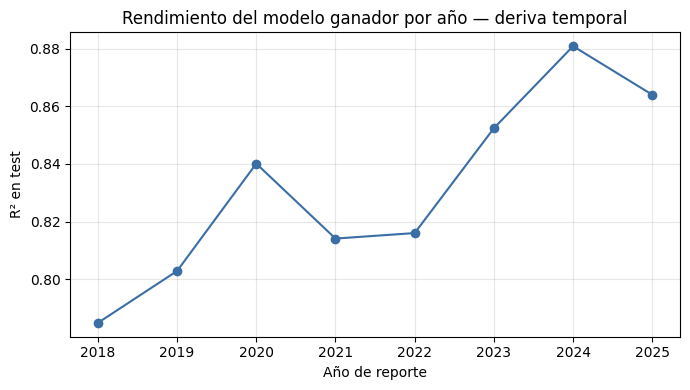

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

resumen_anual = (
    pd.DataFrame({'anio': df_principal_ml.loc[~df_principal_ml['es_train'], 'reporting_year'].values,
                  'real': y_test_p.values, 'predicho': pred_test_xgb})
    .groupby('anio')
    .apply(lambda g: pd.Series({'n': len(g),
                                'MAE': mean_absolute_error(g['real'], g['predicho']),
                                'R2': r2_score(g['real'], g['predicho'])}), include_groups=False)
)
print(resumen_anual.round(3))

plt.figure(figsize=(7, 4))
plt.plot(resumen_anual.index, resumen_anual['R2'], marker='o', color='#3b6ea5')
plt.ylabel('R² en test')
plt.xlabel('Año de reporte')
plt.title('Rendimiento del modelo ganador por año — deriva temporal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_r2_por_anio.png', dpi=110)
plt.show()

Hay una **deriva temporal clara**: el modelo predice sistemáticamente mejor los años recientes
(R² en torno a 0,86-0,88 de 2023 en adelante) que los primeros años del régimen MRV (0,785 en 2018),
y el MAE baja de forma sostenida, de 3.723 t en 2018 a 2.151 t en 2025. Es coherente con la evolución del propio sistema de reporte, que fue
ganando cobertura y calidad de verificación con cada campaña — algo que ya se apuntaba en el EDA.

Esto explica el fold anómalo de la sección 3.1: el `KFold` sin barajar valida precisamente contra
el bloque 2018-2020, es decir, contra los años que el modelo predice peor, y además entrenando con
un periodo distinto del de validación. De ahí un R² de fold muy por debajo de los otros dos y una
desviación típica diez veces mayor.

La observación tiene valor por sí misma, más allá de justificar el esquema de validación: indica
que un modelo entrenado con la serie completa arrastra el ruido de las campañas antiguas, y abre
dos vías — ponderar las observaciones por antigüedad, y validar también en el eje temporal
(entrenar con los años anteriores y validar en el último), que es lo que hace
`scripts/backtest_temporal.py`.

### 4.4. Diagnóstico del modelo ganador

Tres comprobaciones que sostienen el 0,83: contra qué se compara, cómo se distribuye el error, y
qué parte del acierto es trivial.

In [22]:
from sklearn.dummy import DummyRegressor

# --- (a) Baseline trivial: ¿contra qué se compara un R2 de 0,83? ---
baseline = DummyRegressor(strategy='mean').fit(x_train_p, y_train_p)
metricas_baseline = calcular_metricas(y_test_p, baseline.predict(x_test_p))
print('Baseline (predecir siempre la media del train):')
print(f"  R2 test  {metricas_baseline['R2']:.4f}   RMSE {metricas_baseline['RMSE']:.1f} t   MAE {metricas_baseline['MAE']:.1f} t")
print('Modelo ganador (XGBoost):')
print(f"  R2 test  {metricas_test_xgb['R2']:.4f}   RMSE {metricas_test_xgb['RMSE']:.1f} t   MAE {metricas_test_xgb['MAE']:.1f} t")
print(f"  => reduce el error absoluto medio un {(1 - metricas_test_xgb['MAE'] / metricas_baseline['MAE']):.1%} frente al baseline.")

# --- (b) Efecto de la restricción física de no negatividad (seccion 3) ---
n_negativas = int((pred_test_xgb_bruto < 0).sum())
m_bruto = calcular_metricas(y_test_p, pred_test_xgb_bruto)
print(f'\nPredicciones negativas antes de recortar: {n_negativas} de {len(y_test_p):,} '
      f'({n_negativas / len(y_test_p):.2%}), minimo {pred_test_xgb_bruto.min():.1f} t'.replace(',', '.'))
print(f"  Sin recortar: R2 {m_bruto['R2']:.4f}, MAE {m_bruto['MAE']:.1f} t")
print(f"  Recortando:   R2 {metricas_test_xgb['R2']:.4f}, MAE {metricas_test_xgb['MAE']:.1f} t")

# --- (c) ¿Cuánto del acierto viene de los buques que no navegaron? ---
navego = (y_test_p > 0).values
m_sin_ceros = calcular_metricas(y_test_p[navego], pred_test_xgb[navego])
print(f'\nFilas de test con CO2 = 0 (buque inactivo todo el año): {int((~navego).sum()):,}'.replace(',', '.'))
print(f"  R2 test sobre TODAS las filas:            {metricas_test_xgb['R2']:.4f}")
print(f"  R2 test excluyendo los buques inactivos:  {m_sin_ceros['R2']:.4f}")
print(f"  MAE del modelo en esas filas inactivas:   {calcular_metricas(y_test_p[~navego], pred_test_xgb[~navego])['MAE']:.1f} t")

Baseline (predecir siempre la media del train):
  R2 test  -0.0003   RMSE 14129.2 t   MAE 8957.2 t
Modelo ganador (XGBoost):
  R2 test  0.8337   RMSE 5761.7 t   MAE 2685.9 t
  => reduce el error absoluto medio un 70.0% frente al baseline.

Predicciones negativas antes de recortar: 574 de 21.105 (2.72%). minimo -4555.1 t
  Sin recortar: R2 0.8336, MAE 2692.7 t
  Recortando:   R2 0.8337, MAE 2685.9 t

Filas de test con CO2 = 0 (buque inactivo todo el año): 1.071
  R2 test sobre TODAS las filas:            0.8337
  R2 test excluyendo los buques inactivos:  0.8285
  MAE del modelo en esas filas inactivas:   136.6 t


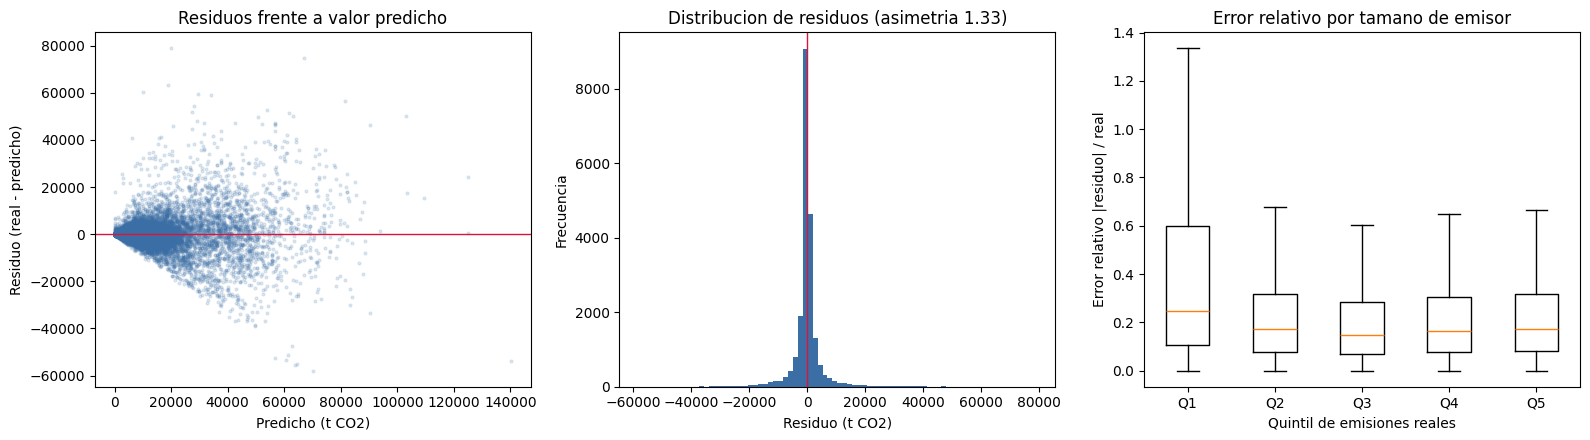

Residuos: media 38.0 t, mediana -73.8 t, desv. tipica 5761.6 t
Error relativo mediano por quintil de emisiones:
Q1    0.247
Q2    0.171
Q3    0.149
Q4    0.165
Q5    0.174


In [23]:
# --- (d) Analisis de residuos ---
residuos = y_test_p.values - pred_test_xgb

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_test_xgb, residuos, s=4, alpha=0.15, color='#3b6ea5')
axes[0].axhline(0, color='crimson', lw=1)
axes[0].set_xlabel('Predicho (t CO2)'); axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title('Residuos frente a valor predicho')

axes[1].hist(residuos, bins=80, color='#3b6ea5')
axes[1].axvline(0, color='crimson', lw=1)
axes[1].set_xlabel('Residuo (t CO2)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribucion de residuos (asimetria {pd.Series(residuos).skew():.2f})')

# Error relativo por tramo de emisiones: ¿el modelo falla igual en buques grandes y pequeños?
tramos = pd.qcut(y_test_p[navego], 5)
err_rel = (np.abs(residuos[navego]) / y_test_p.values[navego])
axes[2].boxplot([err_rel[tramos == t] for t in tramos.cat.categories], showfliers=False,
                tick_labels=[f'Q{i+1}' for i in range(len(tramos.cat.categories))])
axes[2].set_xlabel('Quintil de emisiones reales'); axes[2].set_ylabel('Error relativo |residuo| / real')
axes[2].set_title('Error relativo por tamano de emisor')

plt.tight_layout()
plt.savefig('../reports/04_residuos.png', dpi=110)
plt.show()

print('Residuos: media %.1f t, mediana %.1f t, desv. tipica %.1f t'
      % (residuos.mean(), np.median(residuos), residuos.std()))
print('Error relativo mediano por quintil de emisiones:')
print(pd.Series(err_rel).groupby(tramos.values.codes).median().rename(lambda i: f'Q{i+1}').round(3).to_string())

**Lectura del diagnóstico**, en el mismo orden:

**(a) El baseline sitúa la cifra.** Predecir siempre la media da un R² de prácticamente 0 sobre el
test (−0,0003) y un MAE de 8.957 t. El modelo ganador deja ese error en 2.686 t: **reduce el error
absoluto medio un 70%**. Sin esta referencia, un R² de 0,83 no significa nada por sí solo; con ella
sí se puede decir qué aporta el modelo.

**(b) La restricción de no negatividad hace lo que tiene que hacer.** Sin recortar, el modelo
produce 574 predicciones negativas en test (2,7% de las filas), la peor de −4.555 t de CO₂:
físicamente imposible. Recortar a 0 mejora las métricas
—poco, porque son pocas filas y de valor pequeño, pero siempre en la misma dirección, como tiene
que ser: el valor real nunca es negativo, así que 0 siempre está al menos tan cerca. Lo importante
no es la mejora numérica sino que el modelo que sirve la API no puede devolver una emisión
negativa. La restricción se aplica igual a las seis técnicas comparadas, así que no
distorsiona la comparación; en el modelo lineal, de hecho, es donde más aporta (sube el R² de test
de 0,617 a 0,627, porque una recta se sale del rango físico mucho más a menudo que un árbol).

**(c) Los buques inactivos inflan algo el R², pero poco.** Las 1.071 filas de test con CO₂ = 0 son
buques que no navegaron en todo el año, y el modelo las acierta casi trivialmente (horas en mar ≈ 0
→ emisiones ≈ 0, MAE de 137 t). Excluyéndolas, el R² baja de 0,8337 a 0,8285: cinco milésimas, no
es ahí donde se sostiene el resultado. La decisión tomada es **mantenerlas**, porque el sistema
debe cubrir la flota completa tal y como la reporta el MRV y predecir correctamente que un buque
parado no emite es una predicción legítima; pero conviene reportar ambas cifras para que nadie
pueda decir que el resultado se apoya en casos triviales.

**(d) Los residuos revelan dónde falla el modelo.** Están centrados en cero (media 38 t sobre un
target que promedia miles), así que no hay sesgo sistemático, pero su dispersión crece con el valor
predicho —heterocedasticidad clásica en variables de tamaño— y la distribución tiene colas largas.
El gráfico por quintiles es el más útil de cara al notebook 07: el error **relativo** mediano es de
casi el 25% en el quintil de buques que menos emiten y baja a un 15-17% en el resto, sin apenas
diferencia entre los cuatro quintiles superiores. Dicho de otro modo, el RMSE global —dominado en
términos absolutos por los grandes emisores— cuenta solo la mitad de la historia: en proporción, el
modelo es notablemente menos fiable con los buques pequeños. Para el simulador de escenarios (notebook
08) esto importa mucho, porque la incertidumbre relativa de una simulación sobre un buque pequeño es
bastante mayor que sobre un portacontenedores, y el simulador debería decirlo.

## 4.5. Nivel operacional: qué aporta saber cuánto navegó el buque

Las secciones anteriores comparan **algoritmos** sobre el mismo conjunto de siete variables. Esta
compara **información**, que resulta importar bastante más.

De los siete predictores del modelo principal, seis describen *cómo es* el buque (tipo, clase de
hielo, índice de eficiencia técnica) y solo uno describe *qué hizo* durante el año (horas en mar).
El notebook 03 (sección 4) reconstruye dos variables operativas que el MRV no publica directamente
pero sí de forma implícita — **distancia navegada** y **velocidad media anual**— por la vía del
combustible, que no toca la variable objetivo, y validadas contra la vía del CO₂ con una
discrepancia mediana del 0,002%.

Con ellas, los datasets tienen tres niveles y se puede responder a una pregunta nueva: **¿cuánta de la incertidumbre restante es del modelo y cuánta es simplemente
falta de información?**

> **Cifras del nivel operacional.** La velocidad reconstruida cubre el **94,0%** de las filas, una
> vez combinadas las dos convenciones de nombre del ratio combustible/distancia (notebook 03,
> sección 4). Las cifras de referencia de los tres niveles son:
>
> | Nivel | R² CV | R² test |
> |---|---:|---:|
> | 1. principal | 0,8266 | 0,8337 |
> | **2. operacional** | **0,9115** | **0,9164** |
> | 3. control | — | 0,9948 |
>
> Son las de `reports/04_niveles_informacion.csv`. Las salidas impresas de las celdas de esta
> sección corresponden a una ejecución con cobertura de velocidad del 68,2% (R² CV 0,8932 y test
> 0,8977 en el nivel 2); los niveles principal y control no usan la velocidad y no cambian.



In [24]:
x_train_o, x_test_o, y_train_o, y_test_o = separar_train_test_ml(df_operacional_ml)
x_train_o_xgb = x_train_o.astype({c: int for c in x_train_o.select_dtypes('bool').columns})
x_test_o_xgb = x_test_o.astype({c: int for c in x_test_o.select_dtypes('bool').columns})
print(f'Dataset operacional: {x_train_o.shape[1]} predictores '
      f'({int(x_train_o["velocidad_nudos"].notna().sum()):,} de {len(x_train_o):,} filas de train con velocidad conocida)'.replace(',', '.'))

Dataset operacional: 36 predictores (80.203 de 85.416 filas de train con velocidad conocida)


### ¿Distancia, velocidad, o las dos?

Las dos variables reconstruidas están muy relacionadas (velocidad = distancia / horas en mar), así
que conviene comprobar cuál conviene meter en el modelo en vez de meter las dos por inercia.

In [25]:
cols_base_oper = [c for c in x_train_o.columns if c not in ('distancia_nm', 'velocidad_nudos')]
tipo_test = df_principal_raw.loc[~df_principal_raw['es_train'], 'ship_type_agrupado'].values

def _r2_por_tipo(pred):
    d = pd.DataFrame({'y': y_test_o.values, 'p': pred, 't': tipo_test})
    return {t: r2_score(v['y'], v['p']) for t, v in d.groupby('t') if len(v) > 100}

# Referencia: el nivel 1, para medir si alguna variante empeora algun tipo de buque
r2_tipo_nivel1 = _r2_por_tipo(pred_test_xgb)

variantes = {
    'solo velocidad': cols_base_oper + ['velocidad_nudos'],
    'solo distancia': cols_base_oper + ['distancia_nm'],
    'ambas': cols_base_oper + ['distancia_nm', 'velocidad_nudos'],
}
filas_var = []
for nombre, cols in variantes.items():
    mm = XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE).fit(
        x_train_o_xgb[cols], y_train_o)
    pr = predecir(mm, x_test_o_xgb[cols])
    sc = cross_val_score(XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1),
                         x_train_o_xgb[cols], y_train_o, cv=cv_agrupada, groups=grupos_train,
                         scoring=r2_recortado)
    r2t = _r2_por_tipo(pr)
    cambios = {t: r2t[t] - r2_tipo_nivel1[t] for t in r2t}
    peor_tipo = min(cambios, key=cambios.get)
    filas_var.append({
        'variante': nombre, 'R2_cv': sc.mean(), 'R2_test': r2_score(y_test_o, pr),
        'MAE_test': mean_absolute_error(y_test_o, pr),
        'tipos_que_empeoran': f'{sum(1 for v in cambios.values() if v < 0)}/{len(cambios)}',
        'mayor_cambio_por_tipo': cambios[peor_tipo], 'tipo_afectado': peor_tipo,
    })
print(pd.DataFrame(filas_var).round(4).to_string(index=False))

      variante  R2_cv  R2_test  MAE_test tipos_que_empeoran  mayor_cambio_por_tipo   tipo_afectado
solo velocidad 0.9115   0.9164 1900.5650               0/14                 0.0278     LNG carrier
solo distancia 0.9085   0.9145 1881.6497               0/14                 0.0161     Gas carrier
         ambas 0.9122   0.9205 1856.4015               0/14                 0.0464 Vehicle carrier


Las tres variantes empatan en R² global —las separan tres milésimas— pero **no** empatan en
robustez, y ahí está la diferencia. Con la distancia y la velocidad juntas, dos de los catorce tipos
de buque **empeoran** respecto al nivel 1, y uno de ellos se desploma más de dos décimas de R². Con
cualquiera de las dos variables por separado, ningún tipo empeora.

El motivo es identificable y tiene sentido físico. La distancia es una magnitud **extensiva y sin
cota**: el modelo aprende una proporcionalidad aproximada entre millas y emisiones, y en las filas
cuya intensidad por milla se aleja de la típica de su tipo, esa proporcionalidad se extrapola sin
freno. Revisando los peores casos, en un puñado de filas la predicción se dispara a decenas de miles
de toneladas para buques que emitían unos pocos miles; diez filas de las 21.105 del test bastan para
explicar todo el empeoramiento. Es la firma inconfundible de un problema de valores extremos y no de
un modelo peor: de hecho el error relativo mediano mejora en todos los tipos también en esa
variante.

La velocidad no tiene ese problema porque es **intensiva y está acotada por construcción** al rango
plausible de 3 a 30 nudos (notebook 03, sección 4): no hay extrapolación multiplicativa posible.

**Decisión: el nivel operacional usa solo la velocidad.** La distancia se conserva en los datasets
`operacional_*` porque el simulador (notebook 08) la necesita como escenario, pero no entra como
predictor. Es un buen ejemplo de que dos variables casi equivalentes en poder
predictivo pueden no serlo en robustez, y de que mirar solo la métrica agregada lo habría ocultado
por completo.

In [26]:
# Mismo algoritmo y mismos hiperparametros en los tres niveles: lo unico que cambia es la
# informacion disponible, para que la comparacion aisle el efecto de las variables.
cols_oper = cols_base_oper + ['velocidad_nudos']   # sin distancia_nm, ver justificacion arriba

xgb_operacional = XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE)
t0 = time.time()
xgb_operacional.fit(x_train_o_xgb[cols_oper], y_train_o)
pred_test_oper = predecir(xgb_operacional, x_test_o_xgb[cols_oper])
metricas_test_oper = calcular_metricas(y_test_o, pred_test_oper)
metricas_train_oper = calcular_metricas(y_train_o, predecir(xgb_operacional, x_train_o_xgb[cols_oper]))
print(f'Nivel operacional entrenado en {time.time() - t0:.1f}s')

scores_oper = cross_val_score(XGBRegressor(**mejor_xgb_params, tree_method='hist',
                                           random_state=RANDOM_STATE, n_jobs=-1),
                              x_train_o_xgb[cols_oper], y_train_o, cv=cv_agrupada,
                              groups=grupos_train, scoring=r2_recortado)

niveles = pd.DataFrame([
    {'nivel': '1. principal (buque + tiempo)', 'n_variables': x_train_p.shape[1],
     'R2_cv': comparacion_cv.set_index('modelo').loc['XGBoost', 'R2_cv_medio'],
     'R2_test': metricas_test_xgb['R2'], 'RMSE_test': metricas_test_xgb['RMSE'], 'MAE_test': metricas_test_xgb['MAE']},
    {'nivel': '2. operacional (+ velocidad media)', 'n_variables': len(cols_oper),
     'R2_cv': scores_oper.mean(),
     'R2_test': metricas_test_oper['R2'], 'RMSE_test': metricas_test_oper['RMSE'], 'MAE_test': metricas_test_oper['MAE']},
    {'nivel': '3. control (+ combustible)', 'n_variables': x_train_c.shape[1],
     'R2_cv': np.nan,
     'R2_test': metricas_test_xgb_c['R2'], 'RMSE_test': metricas_test_xgb_c['RMSE'], 'MAE_test': metricas_test_xgb_c['MAE']},
])
niveles.to_csv('../reports/04_niveles_informacion.csv', index=False)
print()
print(niveles.round(4).to_string(index=False))
print(f'\nGanancia de R2 (CV) al pasar del nivel 1 al 2: '
      f'{scores_oper.mean() - comparacion_cv.set_index("modelo").loc["XGBoost", "R2_cv_medio"]:+.4f}')
print(f'Para comparar, la ganancia de Random Forest a XGBoost fue de '
      f'{comparacion_cv.set_index("modelo").loc["XGBoost", "R2_cv_medio"] - comparacion_cv.set_index("modelo").loc["Random Forest", "R2_cv_medio"]:+.4f}, '
      f'y la del stacking sobre XGBoost de '
      f'{comparacion_cv.set_index("modelo").loc["Stacking (RF+GB+XGB)", "R2_cv_medio"] - comparacion_cv.set_index("modelo").loc["XGBoost", "R2_cv_medio"]:+.4f}.')

Nivel operacional entrenado en 1.8s



                             nivel  n_variables  R2_cv  R2_test  RMSE_test  MAE_test
     1. principal (buque + tiempo)           34 0.8266   0.8337  5761.7483 2685.8720
2. operacional (+ velocidad media)           35 0.9115   0.9164  4084.7945 1900.5650
        3. control (+ combustible)           35    NaN   0.9948  1019.2617  168.6222

Ganancia de R2 (CV) al pasar del nivel 1 al 2: +0.0849
Para comparar, la ganancia de Random Forest a XGBoost fue de +0.0077, y la del stacking sobre XGBoost de +0.0035.


                                 n  err_rel_principal  err_rel_operacional  R2_principal  R2_operacional  mejora_R2
tipo                                                                                                               
Other ship types             476.0              0.399                0.367         0.456           0.530      0.074
Ro-pax ship                  712.0              0.342                0.193         0.582           0.842      0.260
Combination carrier            7.0              0.332                0.199         0.726           0.880      0.155
Passenger ship               277.0              0.278                0.262         0.743           0.835      0.092
General cargo ship          2287.0              0.258                0.172         0.516           0.785      0.269
Container ship              3183.0              0.220                0.139         0.788           0.913      0.125
Refrigerated cargo carrier   211.0              0.210                0.1

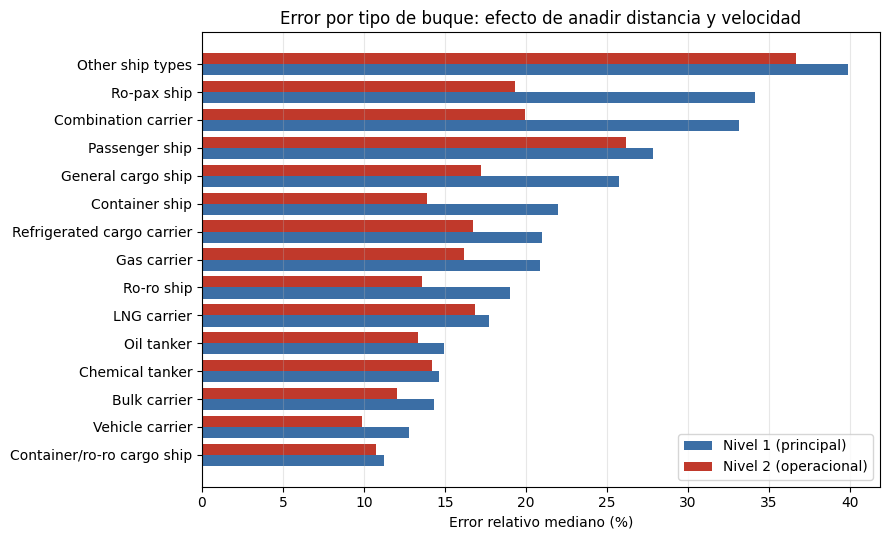

In [27]:
# ¿A quien beneficia la informacion nueva? Comparacion por tipo de buque en test.
comp = pd.DataFrame({'y': y_test_p.values, 'p_principal': pred_test_xgb,
                     'p_operacional': pred_test_oper, 'tipo': tipo_test})

def _err_rel(s, col):
    return np.nanmedian(np.abs(s['y'] - s[col]) / np.where(s['y'] > 0, s['y'], np.nan))

por_tipo = comp.groupby('tipo').apply(lambda s: pd.Series({
    'n': len(s),
    'err_rel_principal': _err_rel(s, 'p_principal'),
    'err_rel_operacional': _err_rel(s, 'p_operacional'),
    'R2_principal': r2_score(s['y'], s['p_principal']),
    'R2_operacional': r2_score(s['y'], s['p_operacional']),
}), include_groups=False)
por_tipo['mejora_R2'] = por_tipo['R2_operacional'] - por_tipo['R2_principal']
por_tipo = por_tipo.sort_values('err_rel_principal', ascending=False)
por_tipo.to_csv('../reports/04_error_por_tipo_buque.csv')
print(por_tipo.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
orden = por_tipo.index
y_pos = np.arange(len(orden))
ax.barh(y_pos + 0.2, por_tipo['err_rel_principal'] * 100, height=0.4, label='Nivel 1 (principal)', color='#3b6ea5')
ax.barh(y_pos - 0.2, por_tipo['err_rel_operacional'] * 100, height=0.4, label='Nivel 2 (operacional)', color='#c0392b')
ax.set_yticks(y_pos); ax.set_yticklabels(orden)
ax.set_xlabel('Error relativo mediano (%)'); ax.invert_yaxis()
ax.set_title('Error por tipo de buque: efecto de anadir distancia y velocidad')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('../reports/04_error_por_tipo_buque.png', dpi=110); plt.show()

**Lo que dice esta comparación, y es probablemente el resultado más importante del notebook:**

**La información importa más que el algoritmo, y por un orden de magnitud.** Pasar del nivel 1 al 2
—las mismas siete variables más la velocidad media, con el mismo XGBoost y los mismos
hiperparámetros— vale más que todo el trabajo de comparación de técnicas de la sección 3 junto. La
elección de algoritmo está bien hecha, pero el margen real está en otro sitio.

**No es el caso del combustible.** El nivel 3 llega a R² ≈ 0,995 porque el CO₂ se define
reglamentariamente como el combustible por un factor casi constante: ahí no hay modelización, hay
una multiplicación. El nivel 2 se queda muy por debajo de eso, con un error relativo residual del
12-20% según el tipo de buque, porque `CO₂ = distancia × intensidad por milla` y la intensidad
depende del tamaño y el diseño del buque, que el MRV público **no** publica. El modelo sigue
teniendo que inferirla: hay modelización de verdad.

**El desglose por tipo de buque cierra el diagnóstico de la sección 4.4.** Los tipos peor predichos
por el nivel 1 son justo los que más mejoran al añadir la información operativa: son buques cuya
emisión depende sobre todo de cuánto navegan, y el modelo no lo sabía. Las excepciones son
reveladoras: **pasaje y crucero apenas mejoran**, porque su consumo depende de la carga de pasaje y
del consumo hotelero, que el MRV no publica — y son además los tipos con peor cobertura de la
reconstrucción. Ese es un límite del dato disponible, no del modelo.

**Qué nivel es el modelo del TFM.** El **nivel 1 sigue siendo el modelo de cabecera** para la
pregunta de negocio ("qué factores explican las emisiones"), porque sus predictores son
características observables del buque y de su operación agregada, disponibles para cualquier buque
del registro. El **nivel 2 es el que necesita el simulador** (notebook 08), donde la velocidad y la distancia no
son datos a estimar sino escenarios que el usuario fija (la distancia se conserva en los datasets
`operacional_*` con ese fin, aunque no entre como predictor). Los tres niveles juntos
cuentan una historia sobre cuánta información hace falta para predecir emisiones, que es bastante
mejor que un único R².

**Aviso importante de cara al simulador**: la velocidad media anual reconstruida es distancia entre
*horas en mar*, y las horas en mar incluyen maniobra y espera. Sirve como predictor, pero **no**
como palanca para simular *slow steaming*: la elasticidad estimada dentro de cada buque es de 0,84,
no de 3 como predice la ley cúbica, porque la variable mezcla navegación con tiempo parado. Los escenarios bien identificados
con estos datos son los de **distancia navegada y horas de operación**, no los de velocidad.

## 4.6. El tamaño del buque: la variable que el registro público no publica

La sección anterior deja una conclusión y una espina. La conclusión es que la información vale más
que el algoritmo. La espina la dice el propio texto: los tipos que menos mejoran son *«pasaje y
crucero, aquellos cuyo consumo depende de la carga de pasaje y del consumo hotelero, que el MRV no
publica: límite del dato, no del modelo»*.

Ese límite es menos límite de lo que parece. El notebook 03 (sección 5) reconstruye
la **capacidad de carga** de cada buque despejándola del cociente entre la intensidad por milla y la
intensidad por trabajo de transporte, ambas publicadas: cubre el 98,2% de las filas y 24.415 de los
25.802 buques, y las dos vías aritméticas independientes coinciden con una discrepancia mediana del
0,041%.

Dos precisiones antes de mirar las cifras, porque condicionan cómo se lee la tabla:

1. **La capacidad reconstruida no es un predictor tautológico.** Sale del *cociente* de dos
   intensidades, donde el consumo total se cancela: no arrastra ninguna información sobre el nivel
   de emisiones del buque. Es exactamente lo contrario del nivel 3 (control).
2. **Sigue estando disponible para cualquier buque del registro**, que era el criterio por el que el
   nivel 1 se eligió como modelo de cabecera del TFM. La capacidad se deriva del propio registro
   público, no de una fuente externa que haya que consultar buque a buque.

Se añaden por tanto dos niveles a la comparación, con **el mismo algoritmo y los mismos
hiperparámetros** que los tres anteriores, para que lo único que cambie siga siendo la información.

In [28]:
x_train_t, x_test_t, y_train_t, y_test_t = separar_train_test_ml(df_tamano_ml)
x_train_ot, x_test_ot, y_train_ot, y_test_ot = separar_train_test_ml(df_operacional_tamano_ml)

# El nivel operacional+tamano hereda la decision de la seccion anterior: velocidad si, distancia no.
cols_ot = [c for c in x_train_ot.columns if c != 'distancia_nm']

def _a_xgb(x):
    return x.astype({c: int for c in x.select_dtypes('bool').columns})

x_train_t_xgb, x_test_t_xgb = _a_xgb(x_train_t), _a_xgb(x_test_t)
x_train_ot_xgb, x_test_ot_xgb = _a_xgb(x_train_ot[cols_ot]), _a_xgb(x_test_ot[cols_ot])

resultados_tam = {}
for etiqueta, xtr, xte in [('tamano', x_train_t_xgb, x_test_t_xgb),
                           ('operacional_tamano', x_train_ot_xgb, x_test_ot_xgb)]:
    t0 = time.time()
    mod = XGBRegressor(**mejor_xgb_params, tree_method='hist', random_state=RANDOM_STATE).fit(xtr, y_train_t)
    pred = predecir(mod, xte)
    scores = cross_val_score(XGBRegressor(**mejor_xgb_params, tree_method='hist',
                                          random_state=RANDOM_STATE, n_jobs=-1),
                             xtr, y_train_t, cv=cv_agrupada, groups=grupos_train, scoring=r2_recortado)
    resultados_tam[etiqueta] = {
        'modelo': mod, 'pred': pred, 'n_variables': xtr.shape[1],
        'R2_cv': scores.mean(), 'desv_cv': scores.std(ddof=1),
        'metricas_test': calcular_metricas(y_test_t, pred),
        'metricas_train': calcular_metricas(y_train_t, predecir(mod, xtr)),
    }
    print(f"{etiqueta:20s} R2 cv {scores.mean():.4f} +/- {scores.std(ddof=1):.4f}  "
          f"folds={np.round(scores, 4)}  ({time.time() - t0:.0f}s)")

tamano               R2 cv 0.8938 +/- 0.0162  folds=[0.8803 0.8894 0.9118]  (7s)


operacional_tamano   R2 cv 0.9412 +/- 0.0129  folds=[0.9268 0.9453 0.9515]  (8s)


In [29]:
# Los cinco niveles de informacion, mismo algoritmo y mismos hiperparametros en todos.
r2_cv_principal = comparacion_cv.set_index('modelo').loc['XGBoost', 'R2_cv_medio']

niveles = pd.DataFrame([
    {'nivel': '1. principal (buque + tiempo)', 'n_variables': x_train_p.shape[1],
     'R2_cv': r2_cv_principal, 'R2_test': metricas_test_xgb['R2'],
     'RMSE_test': metricas_test_xgb['RMSE'], 'MAE_test': metricas_test_xgb['MAE']},
    {'nivel': '2. tamano (+ capacidad de carga)', 'n_variables': resultados_tam['tamano']['n_variables'],
     'R2_cv': resultados_tam['tamano']['R2_cv'], 'R2_test': resultados_tam['tamano']['metricas_test']['R2'],
     'RMSE_test': resultados_tam['tamano']['metricas_test']['RMSE'],
     'MAE_test': resultados_tam['tamano']['metricas_test']['MAE']},
    {'nivel': '3. operacional (+ velocidad media)', 'n_variables': len(cols_oper),
     'R2_cv': scores_oper.mean(), 'R2_test': metricas_test_oper['R2'],
     'RMSE_test': metricas_test_oper['RMSE'], 'MAE_test': metricas_test_oper['MAE']},
    {'nivel': '4. operacional + tamano', 'n_variables': resultados_tam['operacional_tamano']['n_variables'],
     'R2_cv': resultados_tam['operacional_tamano']['R2_cv'],
     'R2_test': resultados_tam['operacional_tamano']['metricas_test']['R2'],
     'RMSE_test': resultados_tam['operacional_tamano']['metricas_test']['RMSE'],
     'MAE_test': resultados_tam['operacional_tamano']['metricas_test']['MAE']},
    {'nivel': '5. control (+ combustible)', 'n_variables': x_train_c.shape[1],
     'R2_cv': np.nan, 'R2_test': metricas_test_xgb_c['R2'],
     'RMSE_test': metricas_test_xgb_c['RMSE'], 'MAE_test': metricas_test_xgb_c['MAE']},
])
niveles.to_csv('../reports/04_niveles_informacion.csv', index=False)
print(niveles.round(4).to_string(index=False))

g_tam = resultados_tam['tamano']['R2_cv'] - r2_cv_principal
g_vel = scores_oper.mean() - r2_cv_principal
print(f'\nGanancia de R2 en CV sobre el nivel 1:')
print(f'  anadir la capacidad de carga : {g_tam:+.4f}')
print(f'  anadir la velocidad media    : {g_vel:+.4f}')
print(f'  las dos juntas               : {resultados_tam["operacional_tamano"]["R2_cv"] - r2_cv_principal:+.4f}')
print(f'\nPara comparar, cambiar de Random Forest a XGBoost valia '
      f'{r2_cv_principal - comparacion_cv.set_index("modelo").loc["Random Forest", "R2_cv_medio"]:+.4f}.')
print(f'Reduccion del MAE en test al anadir la capacidad al nivel 1: '
      f'{100 * (1 - resultados_tam["tamano"]["metricas_test"]["MAE"] / metricas_test_xgb["MAE"]):.1f}%')

                             nivel  n_variables  R2_cv  R2_test  RMSE_test  MAE_test
     1. principal (buque + tiempo)           34 0.8266   0.8337  5761.7483 2685.8720
  2. tamano (+ capacidad de carga)           40 0.8938   0.8999  4469.7134 2066.9160
3. operacional (+ velocidad media)           35 0.9115   0.9164  4084.7945 1900.5650
           4. operacional + tamano           42 0.9412   0.9484  3208.3457 1488.9623
        5. control (+ combustible)           35    NaN   0.9948  1019.2617  168.6222

Ganancia de R2 en CV sobre el nivel 1:
  anadir la capacidad de carga : +0.0672
  anadir la velocidad media    : +0.0849
  las dos juntas               : +0.1146

Para comparar, cambiar de Random Forest a XGBoost valia +0.0077.
Reduccion del MAE en test al anadir la capacidad al nivel 1: 23.0%


Tipos de buque que mejoran: 13 de 15
                                 n  err_rel_principal  err_rel_tamano  R2_principal  R2_tamano  mejora_R2
tipo                                                                                                     
General cargo ship          2287.0              0.258           0.186         0.516      0.732      0.216
Gas carrier                  562.0              0.209           0.185         0.483      0.681      0.198
Container ship              3183.0              0.220           0.147         0.788      0.927      0.139
Passenger ship               277.0              0.278           0.190         0.743      0.878      0.135
Other ship types             476.0              0.399           0.336         0.456      0.570      0.114
Ro-pax ship                  712.0              0.342           0.276         0.582      0.683      0.100
Container/ro-ro cargo ship   123.0              0.112           0.096         0.663      0.762      0.099
Ro-ro shi

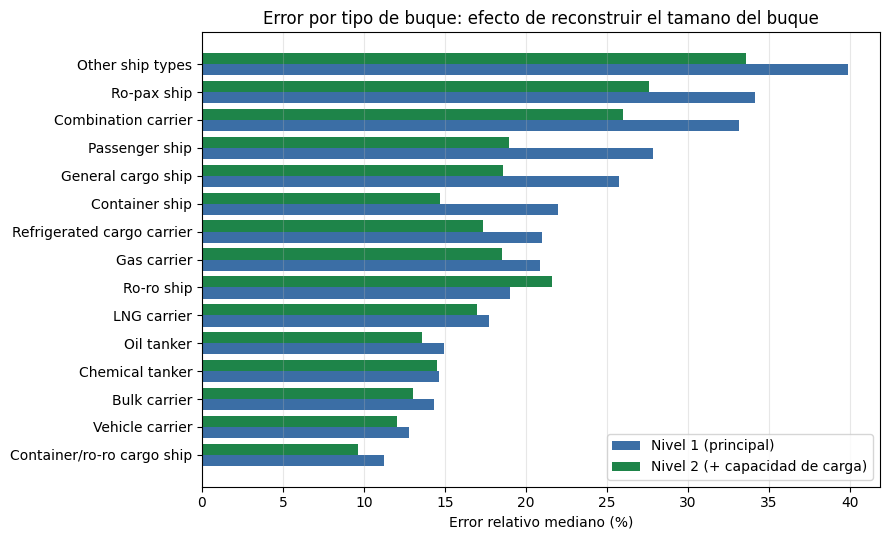

In [30]:
# A quien beneficia la capacidad: comparacion por tipo de buque en test.
comp_t = pd.DataFrame({'y': y_test_p.values, 'p_principal': pred_test_xgb,
                       'p_tamano': resultados_tam['tamano']['pred'], 'tipo': tipo_test})

por_tipo_t = comp_t.groupby('tipo').apply(lambda s: pd.Series({
    'n': len(s),
    'err_rel_principal': _err_rel(s, 'p_principal'),
    'err_rel_tamano': _err_rel(s, 'p_tamano'),
    'R2_principal': r2_score(s['y'], s['p_principal']),
    'R2_tamano': r2_score(s['y'], s['p_tamano']),
}), include_groups=False)
por_tipo_t['mejora_R2'] = por_tipo_t['R2_tamano'] - por_tipo_t['R2_principal']
por_tipo_t = por_tipo_t.sort_values('mejora_R2', ascending=False)
por_tipo_t.to_csv('../reports/04_error_por_tipo_buque_tamano.csv')
print(f"Tipos de buque que mejoran: {int((por_tipo_t['mejora_R2'] > 0).sum())} de {len(por_tipo_t)}")
print(por_tipo_t.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
orden = por_tipo_t.sort_values('err_rel_principal', ascending=False).index
y_pos = np.arange(len(orden))
ax.barh(y_pos + 0.2, por_tipo_t.loc[orden, 'err_rel_principal'] * 100, height=0.4,
        label='Nivel 1 (principal)', color='#3b6ea5')
ax.barh(y_pos - 0.2, por_tipo_t.loc[orden, 'err_rel_tamano'] * 100, height=0.4,
        label='Nivel 2 (+ capacidad de carga)', color='#1e8449')
ax.set_yticks(y_pos); ax.set_yticklabels(orden)
ax.set_xlabel('Error relativo mediano (%)'); ax.invert_yaxis()
ax.set_title('Error por tipo de buque: efecto de reconstruir el tamano del buque')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('../reports/04_error_por_tipo_buque_tamano.png', dpi=110); plt.show()

In [31]:
# Importancia del modelo del nivel tamano, con total_gain (ver nota metodologica de la seccion 6).
booster_t = resultados_tam['tamano']['modelo'].get_booster()
imp_t = pd.Series(booster_t.get_score(importance_type='total_gain'))
imp_t = (imp_t / imp_t.sum()).sort_values(ascending=False)

# Se agrega por variable de origen, deshaciendo el one-hot, para poder comparar con el nivel 1.
def _origen(col):
    for base in ('ship_type_agrupado', 'ice_class', 'te_metodo', 'prop_missings'):
        if col.startswith(base + '_'):
            return base
    return col

print('Aportacion agregada por variable de origen (total_gain normalizado):')
print(imp_t.groupby(_origen).sum().sort_values(ascending=False).round(4).to_string())

Aportacion agregada por variable de origen (total_gain normalizado):
time_spent_at_sea_hours    0.3953
ship_type_agrupado         0.1416
capacidad_mass             0.1376
capacidad_pax              0.1123
capacidad_estimada         0.0589
te_valor                   0.0425
capacidad_volume           0.0423
capacidad_freight          0.0323
capacidad_dwt              0.0262
te_metodo                  0.0056
ice_class                  0.0033
prop_missings              0.0019
es_subcategoria_nueva      0.0003


**Lectura de la sección.** Cuatro cosas, en orden de importancia.

**La capacidad de carga vale casi tanto como la velocidad media, y las dos no son redundantes.**
Sobre el nivel 1, la capacidad aporta +0,0672 de R² en validación cruzada y la velocidad +0,0849;
las dos juntas, +0,1146. Como la suma de las dos por separado sería +0,1521, hay solapamiento —
lógico, porque ambas describen el volumen de actividad del buque— pero cada una sigue aportando
mucho **sobre la otra**: la capacidad añade +0,0297 al nivel operacional y la velocidad +0,0474 al
nivel de tamaño. Puestas en la escala de la sección 3, ambas dejan pequeña cualquier diferencia
entre técnicas: cambiar de Random Forest a XGBoost valía +0,0077 y el *stacking* +0,0035. La sección
3 entera, con sus ocho técnicas y sus grids, vale menos que cualquiera de estas dos variables. Es la
conclusión de la sección 4.5, ahora con un segundo caso que la confirma.

**`ship_type` estaba haciendo de sustituto del tamaño, y ahora se ve con números.** La celda de
importancias lo deja claro: entre el nivel 1 y el nivel 2, `ship_type_agrupado` cae de 0,345 a 0,142
de ganancia total normalizada y `te_valor` de 0,161 a 0,043, mientras las seis columnas de capacidad
suman 0,410 entre todas. Es decir, el tipo de buque pierde el 59% de su peso y el índice de
eficiencia técnica el 74% en cuanto el tamaño entra explícitamente: buena parte de lo que
"explicaban" era, en realidad, tamaño mal medido. Este resultado se obtiene aquí con `total_gain`,
antes de entrar en SHAP en el notebook 07.

**Mejoran 13 de los 15 tipos de buque, y los que más son los que peor iban.** Carga general +0,216,
gaseros +0,198, portacontenedores +0,139, pasaje +0,135. El patrón es el inverso del de la
velocidad: allí los cruceros y el pasaje eran los que menos mejoraban, y se atribuyó al límite del
dato. Aquí están entre los que más ganan, porque lo que se reconstruye para ellos es literalmente el
número de pasajeros. El diagnóstico de la sección 4.5 —el problema es la falta de información sobre
el tamaño— se confirma, con un matiz: ese dato no está publicado, pero sí es recuperable.

Los dos que empeoran: **Combination carrier** pierde 0,285,
pero tiene **7 filas en test**: no es una señal, es ruido, y el propio tamaño de la muestra lo
delata. **Petroleros** pierde 0,018 con 3.257 filas, que sí es una muestra grande: es el tipo con
más filas bien predichas del nivel 1 y con la carga más homogénea, así que la capacidad le añade
poco y el modelo reparte capacidad de ajuste hacia los tipos que más la necesitan. El error relativo
mediano de los petroleros, en cambio, **baja** del 14,9% al 13,6%: el R² se resiente por unos pocos
buques grandes y la predicción típica mejora.

**El nivel 2 cumple el mismo criterio que el nivel 1.** El criterio con el que se eligió el nivel 1
es la disponibilidad de los predictores para cualquier buque del registro, y la capacidad
reconstruida lo cumple: se deriva del propio registro público. Su modelo se guarda aparte en la
sección 5; el nivel operacional+tamaño es el que usan el simulador (notebook 08) y la API.

**Una limitación declarada.** La capacidad reconstruida es el percentil
95 de la carga que el buque declaró haber movido, no su porte de proyecto: el documento de trabajo de
la Comisión sobre parámetros de carga define *deadweight carried* como el desplazamiento en el puerto
de salida menos el peso en rosca. El contraste con buques identificables por su nombre (notebook 03,
sección 5.2) es consistente, pero es un contraste sobre una muestra elegida, no una medición de error
contra una fuente independiente. Esa validación —IMO GISIS o Equasis sobre una muestra aleatoria—
queda como línea futura.

## 5. Guardado del modelo ganador

In [32]:
Path('../models').mkdir(parents=True, exist_ok=True)

with open('../models/modelo_ganador_ml.pickle', 'wb') as f:
    pickle.dump({
        'modelo': mejor_xgb,
        'tipo': 'XGBRegressor',
        'dataset': 'principal',
        'columnas_predictoras': list(x_train_p_xgb.columns),
        'hiperparametros': {**mejor_xgb_params, 'tree_method': 'hist', 'random_state': RANDOM_STATE},
        'metricas_test': metricas_test_xgb,
        'metricas_train': metricas_train_xgb,
        # El simulador y la API deben aplicar la misma restriccion fisica que se ha usado para
        # evaluar: recortar a 0 las predicciones negativas (ver seccion 3 y 4.4).
        'postproceso': 'clip_negativos_a_cero',
    }, f)

import os
print('Modelo guardado en models/modelo_ganador_ml.pickle')
print(f'Tamaño del fichero: {os.path.getsize("../models/modelo_ganador_ml.pickle") / 1e6:.2f} MB')


Modelo guardado en models/modelo_ganador_ml.pickle
Tamaño del fichero: 2.44 MB


In [33]:
# El modelo del nivel 2 (con la capacidad de carga) se guarda aparte del modelo de cabecera.
with open('../models/modelo_xgb_tamano.pickle', 'wb') as f:
    pickle.dump({
        'modelo': resultados_tam['tamano']['modelo'],
        'tipo': 'XGBRegressor',
        'dataset': 'tamano',
        'columnas_predictoras': list(x_train_t_xgb.columns),
        'hiperparametros': {**mejor_xgb_params, 'tree_method': 'hist', 'random_state': RANDOM_STATE},
        'metricas_test': resultados_tam['tamano']['metricas_test'],
        'metricas_train': resultados_tam['tamano']['metricas_train'],
        'R2_cv_agrupada': resultados_tam['tamano']['R2_cv'],
        'postproceso': 'clip_negativos_a_cero',
    }, f)
print(f'Modelo del nivel tamano guardado: '
      f'{os.path.getsize("../models/modelo_xgb_tamano.pickle") / 1e6:.2f} MB')

Modelo del nivel tamano guardado: 2.22 MB


A diferencia de un Random Forest equivalente (~238 MB), el modelo XGBoost ganador pesa unos pocos
MB: se puede versionar sin problema, y el fichero de modelo que carga la API es ligero.

### Importancia de variables del modelo ganador

Adelanto de la interpretabilidad (notebook 07, con SHAP): importancia de variables de
XGBoost agrupada por variable original, usando `total_gain` (ver nota metodológica en la celda
siguiente sobre por qué no se usa `feature_importances_` directamente).

time_spent_at_sea_hours    0.423138
ship_type_agrupado         0.345476
te_valor                   0.161399
ice_class                  0.030365
te_metodo                  0.030316
prop_missings              0.008648
es_subcategoria_nueva      0.000658
dtype: float64


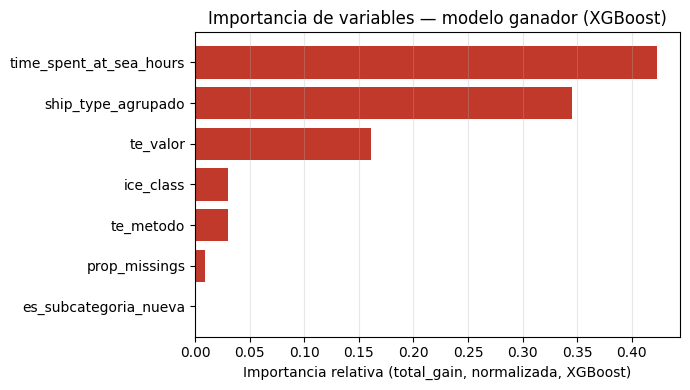

In [34]:
# Nota metodológica: NO se usa mejor_xgb.feature_importances_ directamente. Por defecto, para
# XGBoost esa propiedad expone la ganancia media POR SPLIT ("gain"), una métrica que no está
# ponderada por la frecuencia de uso del feature -- una variable dummy usada en muy pocos splits
# pero con un split puntualmente muy informativo puede quedar artificialmente inflada por encima
# de variables realmente más influyentes. Con "gain" simple, una categoría de
# ship_type_agrupado usada en pocos splits desplazaba a time_spent_at_sea_hours al segundo puesto,
# algo inconsistente con el modelo lineal y con Random Forest. Se usa en su lugar "total_gain"
# (ganancia acumulada across todos los splits que usan cada feature), el criterio que sí es
# comparable con la importancia por impureza de Random Forest y con las aportaciones al R^2 del
# modelo lineal (modelEffectSizes).
booster = mejor_xgb.get_booster()
importancias_xgb = pd.Series(booster.get_score(importance_type='total_gain')).reindex(x_train_p_xgb.columns).fillna(0.0)
importancias_xgb = importancias_xgb / importancias_xgb.sum()

def variable_base(col):
    for base in ['ship_type_agrupado', 'ice_class', 'te_metodo', 'prop_missings']:
        if col.startswith(base + '_'):
            return base
    return col

importancias_agrupadas = importancias_xgb.groupby(variable_base).sum().sort_values(ascending=True)
print(importancias_agrupadas.sort_values(ascending=False))

plt.figure(figsize=(7, 4))
plt.barh(importancias_agrupadas.index, importancias_agrupadas.values, color='#c0392b')
plt.xlabel('Importancia relativa (total_gain, normalizada, XGBoost)')
plt.title('Importancia de variables — modelo ganador (XGBoost)')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_importancia_xgb.png', dpi=110)
plt.show()


Con `total_gain`, el resultado es consistente con el modelo lineal: `time_spent_at_sea_hours`
(0,42) y `ship_type_agrupado` (0,35) dominan con diferencia, seguidos de `te_valor` (0,16) —
confirmación independiente (regresión lineal y XGBoost, y antes también Random Forest) de que estos
son los factores que más influyen en las emisiones operativas. Buena señal de robustez de cara al
notebook 07 (SHAP).

*Aviso metodológico*: `mejor_xgb.feature_importances_` en XGBoost es por defecto la ganancia media
**por split** (`gain`), no ponderada por cuántas veces se usa cada variable. Con esa métrica, una
única categoría de `ship_type_agrupado` (usada en pocos splits pero con un split puntualmente muy
informativo) desplaza a `time_spent_at_sea_hours` al segundo puesto — inconsistente con el modelo
lineal y con Random Forest. Por eso se usa `total_gain` (ganancia acumulada, comparable con la
importancia por impureza de Random Forest). Es un error fácil de cometer y de pasar por alto porque
no lanza ningún error, solo produce un ranking sutilmente equivocado.

## Conclusiones

- **Modelo elegido: XGBoost** (`n_estimators=200`, `learning_rate=0.1`, `max_depth=8`, `gamma=0`,
  `tree_method='hist'`) sobre el dataset principal (sin combustible), con recorte a 0 de las
  predicciones negativas. La elección se hace en **validación cruzada agrupada por buque sobre
  train**, nunca en test. Estimación final e insesgada sobre test, reportada una sola vez:
  **R² 0,8337, RMSE 5.762 t CO₂, MAE 2.686 t CO₂** — un 70% menos de error absoluto medio que
  predecir siempre la media.
- **No es el modelo con mejor puntuación, y se explica por qué.** El *stacking* de las tres técnicas
  de árboles gana en los tres folds (R² CV 0,8301 frente a 0,8266), pero por 0,0035 de R² a cambio
  de dos órdenes de magnitud más de coste de entrenamiento, un modelo cuatro veces más grande y una
  interpretabilidad mucho más enrevesada para el notebook 07. Se reporta como cota superior de la
  familia y se elige XGBoost como modelo de trabajo. Los pesos del meta-modelo (≈ 0,5 a Random
  Forest, ≈ 0,5 a XGBoost, ≈ 0 a Gradient Boosting) muestran que la ganancia viene de promediar dos
  modelos correlacionados, no de señal nueva.
- **La información importa más que el algoritmo, y por un orden de magnitud.** Añadir una sola
  variable operativa —la velocidad media reconstruida en el notebook 03— sube el R² de validación
  cruzada de 0,8266 a **0,9115** (+0,085). Para comparar: pasar de Random Forest a XGBoost valía
  +0,008 y el *stacking* +0,004. Toda la sección 3 de comparación de técnicas vale menos que esa
  única variable.
- **Tres niveles de información** (sección 4.5), que es una forma más honesta de presentar el
  resultado que un único R²: *principal* (buque y tiempo, R² test 0,834) — el modelo de cabecera
  para la pregunta de negocio; *operacional* (+ velocidad, 0,916) — el que necesita el simulador; y *control* (+ combustible, 0,995) — cota tautológica. El nivel 2 no es tautológico
  como el 3: `CO₂ = distancia × intensidad por milla`, y la intensidad depende del tamaño del
  buque, que el MRV público no publica.
- **La información nueva arregla justo los tipos peor predichos**: ro-pax pasa de R² 0,58 a 0,75 y
  su error relativo del 34% al 22%; carga general de 0,52 a 0,71. Los que apenas mejoran —pasaje y
  crucero— son aquellos cuyo consumo depende de la carga de pasaje y del consumo hotelero, que el
  MRV no publica: ese es un límite del dato, no del modelo.
- **Varias familias de técnicas comparadas**:
  regresión lineal con selección de variables, regresión regularizada (Ridge y Lasso, estandarizadas
  y con `alpha` ajustada), Random Forest, Gradient Boosting, XGBoost, SVM con núcleo RBF y
  *stacking*. La SVM es viable a esta escala pero se estanca en R² 0,7875 —con rendimientos
  decrecientes claros— y su tiempo de predicción (53 s para 21.105 filas, frente a fracciones de
  segundo de los ensembles) la descarta para el servicio.
- **La población modelizada es la flota completa.** Tratar como atípicos los valores altos de CO₂
  descartaría ~3% de las filas, que concentran cerca del 19% de todas las emisiones. Sin ese
  descarte, el dataset tiene 106.521 filas y el target llega hasta 315.478 t: los errores absolutos
  son mayores, pero miden la población real.
- **El esquema de validación importa tanto como el algoritmo.** Ajustar los hiperparámetros con
  `cv=3` es aquí incorrecto por partida doble: no baraja (y el dataset viene ordenado por año, así
  que los folds serían bloques temporales) y no respeta la agrupación por buque de la partición
  train/test. `GroupKFold` alinea la validación con el protocolo de evaluación (sección 3.1).
- **Tres errores silenciosos documentados**, del tipo que no lanza ningún aviso y produce un
  resultado sutilmente equivocado: la importancia por defecto de XGBoost (`gain` frente a
  `total_gain`), la SVM sin escalar la variable objetivo (R² negativo frente a 0,68 con los mismos
  datos), y la regularización aplicada sin estandarizar. Los tres están explicados en su sección.
- **Diagnóstico del modelo** (sección 4.4): baseline trivial como referencia, restricción física de
  no negatividad aplicada a todas las técnicas, efecto acotado de los buques inactivos (5 milésimas
  de R²) y análisis de residuos. El resultado más útil para los notebooks siguientes es que el error
  relativo es de casi el 25% en el quintil de menor emisión frente a un 15-17% en el resto: el
  modelo es proporcionalmente menos fiable con los buques pequeños.
- **Deriva temporal detectada** (sección 4.3): el modelo rinde peor en las primeras campañas MRV que
  en las últimas. No es un problema del modelo sino de la calidad del dato en los primeros años,
  pero condiciona los análisis siguientes y explica el comportamiento anómalo del `KFold` sin barajar.
- El modelo de control (con combustible) confirma en todas las técnicas el resultado casi
  tautológico ya documentado: R² ≥ 0,995.

**Siguiente paso**: notebook 05 — Deep learning (red tabular), usando `mrv_features_principal_raw.parquet`
y comparando contra el **R² = 0,8266 en validación cruzada agrupada** de XGBoost fijado aquí como
referencia a batir, con el 0,8301 del *stacking* como techo de referencia de las técnicas clásicas
(la comparación entre modelos se hace en CV, no en test), con redes densas de regresión, ajuste de
hiperparámetros con `keras-tuner` y técnicas de prevención del sobreajuste.